# NB07 — Módulo Predictivo PAC

**Pipeline:** PAC_v2 · Gold v1.2  
**Depende de:** NB01–NB06 (morfotipos C1–C5, estados PAC multiescala, acoplamiento, LOPO-CV)  
**Cohorte de análisis:** `cohort_strict` (8 pacientes, 494 noches, 76.053 eventos)  
**Validación:** LOPO-CV estricto (leave-one-patient-out)

## Diseño conceptual

### Motivación

NB05 demostró que el estado fisiológico PAC condiciona la aparición y severidad de los eventos
de desaturación (EDO): estados patológicos concentran eventos C4/C5 con RR ≈ 11× y la
resiliencia post-evento es prácticamente nula a escala L (1.7%). Esta estructura descriptiva
abre una pregunta clínica concreta:

> **¿Puede el sistema predecir un EDO severo con anticipación suficiente para una intervención?  
> ¿Puede clasificar el perfil de riesgo de una noche completa a partir de su dinámica fisiológica?**

NB07 construye el módulo predictivo PAC en tres niveles complementarios:

1. **Predicción de evento** — dado el contexto fisiológico inmediato anterior a un EDO,
   predecir si será severo (C4/C5). Lead time efectivo: 5 min (M-scale).
2. **Clasificación de noche** — dado el perfil dinámico de una noche, asignarle un
   tier de riesgo clínico. Input: vector de features de `night_multiscale_features`.
3. **Índice de riesgo continuo** — combinar ambos outputs en un score 0–100 actualizable
   que integra riesgo de evento y perfil de noche. Es el output que consume la app.

### Estrategia de validación

Con n=8 pacientes, la única validación honesta es **LOPO-CV** (leave-one-patient-out
cross-validation): entrenar en 7 pacientes, predecir en el 8º, rotar. Esto garantiza que
el modelo nunca ve datos del paciente que está prediciendo — condición necesaria para
cualquier inferencia sobre generalización.

**Nota metodológica:** con este n el modelo predictivo es exploratorio. El objetivo de NB06
es establecer la factibilidad y la magnitud del efecto, no producir un clasificador clínico
validado para uso general. La validación prospectiva en cohorte externa es trabajo futuro.

---

### BLOQUE A — Ingeniería de Features

**A1. Features temporales por evento**  
Para cada EDO se construye una ventana de contexto previa usando el timeline ordenado de
la noche. Features computadas a partir de los N eventos o M minutos anteriores:
- `frac_path_m_30ev`: fracción de los últimos 30 eventos en estado M patológico
- `recent_morph_mean`: severidad media de los últimos 5 morfotipos (0=C1 … 4=C5)
- `ci_so_far`: coupling index acumulado hasta este evento en la noche
- `n_severe_so_far`: número de C4/C5 ocurridos antes en la misma noche
- `state_m_enc`: estado M actual codificado como entero (0–7)
- `state_s_enc`: estado S actual codificado como entero
- `state_l_enc`: estado L actual codificado como entero
- `event_position`: posición relativa del evento en la noche (0=primero, 1=último)
- `pre_state_m_enc`: estado M previo codificado
- `pre_eq_current`: ¿el estado previo es igual al actual? (persistencia)

Target: `is_severe` — C4/C5 vs C1/C2/C3 (binario)

**A2. Matriz de features de noche**  
Selección y verificación de features de `night_multiscale_features.parquet` para el
clasificador de noche. Features candidatas: `ci_s`, `ci_m`, `ci_l`, `coupling_index`,
todas las `frac_state_m_*`, `entropy_state_m`, `pct_severe`, `mean_ari`, `night_traj_cluster`.

Target: `risk_tier` — binario {0: Normal+Leve, 1: Moderado+Severo} para clasificación
principal; multi-clase AASM como análisis secundario.

---

### BLOQUE B — Predicción de Evento

**B1. Baseline logístico — severidad de evento**  
Regresión logística con regularización L2 sobre features de A1. LOPO-CV completo.
Métricas: AUC-ROC, AUC-PR (más informativo con clases desbalanceadas), F1, Brier score.
Referencia de clase desbalanceada: 5.22% de eventos son C4/C5.

**B2. Gradient Boosting — severidad de evento**  
Si logística satura en AUC < 0.75, escalar a GBM (LightGBM). Si logística ≥ 0.78,
la complejidad adicional no está justificada clínicamente.

**B3. Análisis de features importantes**  
Coeficientes logísticos o importancias GBM. ¿Qué features predicen más?
¿El estado actual domina sobre la historia reciente?

**B4. Curvas de performance operacional**  
Sensitivity vs Specificity a distintos umbrales. Definir umbral clínico:
¿cuánta especificidad se sacrifica para capturar el 80% de los eventos severos?

---

### BLOQUE C — Clasificación de Noche

**C1. Preparación de target y features de noche**  
Target binario `risk_tier` = 1 si Moderado o Severo AASM. Distribución: 149/341.
Verificar ausencia de leakage: ninguna feature de noche debe usar información del futuro
intra-noche (las features de NB05 son agregados de la noche completa — válidas para
clasificación retrospectiva, no para predicción en tiempo real).

**C2. Modelos y LOPO-CV**  
Logística + Random Forest. LOPO-CV: entrenar en 7 pacientes (≈430 noches), validar
en 1 (≈60 noches). Repetir 8 veces. AUC, F1, calibración.

**C3. Importancia de features — SHAP**  
¿Qué dimensión fisiológica pesa más para clasificar una noche?
¿`ci_m` domina, o es la combinación de escalas?

---

### BLOQUE D — Índice de Riesgo e Export Gold

**D1. Construcción del índice de riesgo nocturno (0–100)**  
Combina P(evento severo) media intra-noche (Bloque B) con P(noche de alto riesgo)
(Bloque C). Score = clip(0,100) de combinación ponderada, normalizado al rango observado.

**D2. Umbrales clínicos y etiquetas**  
< 30: Riesgo bajo · 30–60: Riesgo moderado (observación) · > 60: Riesgo alto (alerta).  
Umbrales validados por concordancia con AASM tier en datos LOPO-CV.

**D3. Export al Gold**  
Columnas nuevas en `night_multiscale_features.parquet`: `risk_score`, `risk_tier_pred`,
`p_severe_event_mean`, `p_high_risk_night`.

---

### Figuras previstas

| Figura | Contenido |
|---|---|
| 06A_01 | Distribución de features de evento por clase (severo vs no severo) |
| 06A_02 | Correlación y redundancia entre features de noche |
| 06B_01 | Curva ROC y PR — predicción de evento (LOPO-CV) |
| 06B_02 | Importancia de features — predicción de evento |
| 06B_03 | Sensitivity/Specificity vs umbral — curva operacional |
| 06C_01 | Curva ROC — clasificación de noche (LOPO-CV) |
| 06C_02 | SHAP values — clasificación de noche |
| 06C_03 | Matriz de confusión LOPO-CV por paciente |
| 06D_01 | Distribución del índice de riesgo por AASM tier |
| 06D_02 | Score por noche vs pct_severe — calibración visual |

## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib
try:
    get_ipython()
    pass
except NameError:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve,
                              confusion_matrix, classification_report,
                              brier_score_loss)
from sklearn.pipeline import Pipeline
from scipy.stats import mannwhitneyu

ROOT   = Path('..')
GOLD   = ROOT / 'gold'
FIGDIR = Path('figuras')
FIGDIR.mkdir(exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIGDIR / name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  → {FIGDIR / name}')

print(f"GOLD: {GOLD.resolve()}")

plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,
                     'axes.spines.top':False,'axes.spines.right':False,'figure.dpi':150})

MORPH_COLORS = {'C1':'#4878CF','C2':'#6ACC65','C3':'#D65F5F','C4':'#B47CC7','C5':'#C4AD66'}
SEV_COLORS   = {'Normal':'#4878CF','Leve':'#6ACC65','Moderado':'#D65F5F','Severo':'#B47CC7'}
MORPHS = ['C1','C2','C3','C4','C5']

print('Setup completo.')

GOLD: /Users/ri1965/Proyectos/PAC_v2/gold
Setup completo.


## Carga de datos

In [2]:
esm = pd.read_parquet(GOLD / 'event_states_multiscale.parquet')
nmf = pd.read_parquet(GOLD / 'night_multiscale_features.parquet')
nf  = pd.read_parquet(GOLD / 'night_features.parquet')

# Reconstruir cohort_strict: pacientes con ≥10 noches in_strict
nf_ids      = nf[['night_record_id', 'user_id', 'in_strict']].copy()
pat_n       = nf_ids[nf_ids['in_strict']].groupby('user_id').size()
strict_pats = pat_n[pat_n >= 10].index.tolist()
print(f"Pacientes cohort_strict (≥10 noches in_strict): {sorted(strict_pats)}")

# Eventos: filtrar por in_strict y pacientes estrictos
esm_s = esm[esm['in_strict'] == True].copy()
esm_s = esm_s[esm_s['user_id'].isin(strict_pats)].copy()
esm_s = esm_s.rename(columns={'morphotype_curve': 'morph'})
for col in ['state_s_label', 'state_m_label', 'state_l_label']:
    esm_s = esm_s[esm_s[col].notna()]
esm_s['is_severe'] = esm_s['morph'].isin(['C4', 'C5']).astype(int)
esm_s = esm_s.sort_values(['night_record_id', 'ts_start']).reset_index(drop=True)

# Noches: traer user_id e in_strict desde night_features
nmf_s = nmf.merge(nf_ids[['night_record_id', 'user_id', 'in_strict']], on='night_record_id', how='left')
nmf_s = nmf_s[nmf_s['in_strict'] == True].copy()
nmf_s = nmf_s[nmf_s['user_id'].isin(strict_pats)].copy()

print(f"Eventos cohort_strict: {len(esm_s):,} | Pacientes: {esm_s['user_id'].nunique()}")
print(f"Eventos severos: {esm_s['is_severe'].sum():,} ({esm_s['is_severe'].mean()*100:.2f}%)")
print(f"Noches cohort_strict: {len(nmf_s)} | AASM: {dict(nmf_s['aasm_sev'].value_counts())}")

Pacientes cohort_strict (≥10 noches in_strict): ['175', '240', '309', '314', '321', '336', '656', '683']
Eventos cohort_strict: 78,908 | Pacientes: 8
Eventos severos: 4,309 (5.46%)
Noches cohort_strict: 540 | AASM: {'Leve': np.int64(326), 'Moderado': np.int64(148), 'Normal': np.int64(41), 'Severo': np.int64(25)}


---
## BLOQUE A — Ingeniería de Features

### Sección A1 — Features temporales por evento

Computando features de contexto previo...
Dataset evento (con contexto): 76,053 | Severos: 4,238 (5.57%)


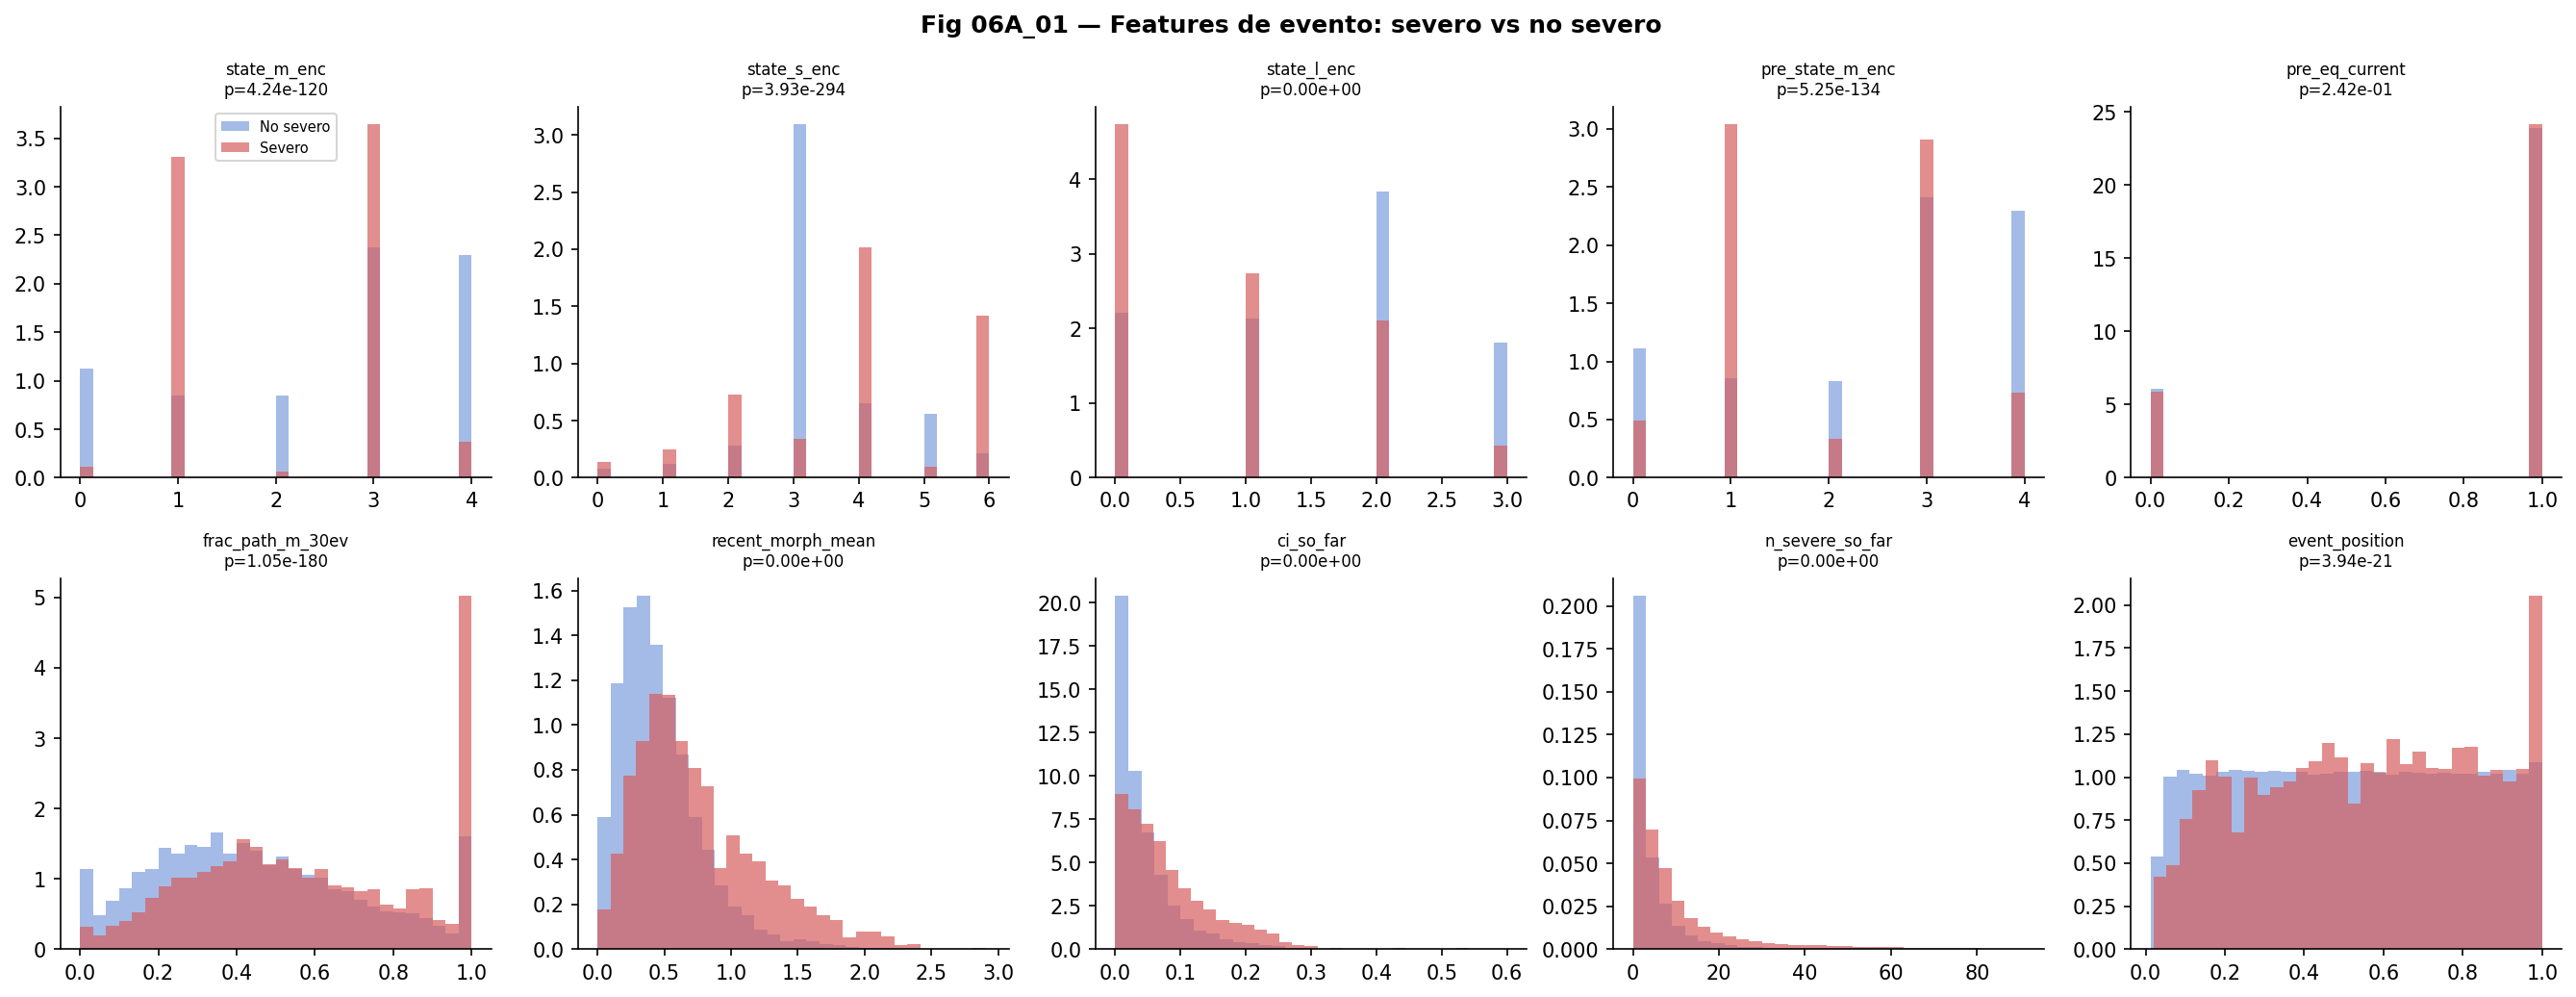

  → figuras/06A_01_features_evento.png


In [3]:
# A1: Encoding de estados y features de contexto previo
def encode_state(col):
    return col.str.extract(r'(\d+)$')[0].astype(float)

esm_s['state_m_enc'] = encode_state(esm_s['state_m_label'])
esm_s['state_s_enc'] = encode_state(esm_s['state_s_label'])
esm_s['state_l_enc'] = encode_state(esm_s['state_l_label'])
# pre_state_m: estado M del evento anterior en la noche (no existe en parquet, se computa aquí)
esm_s['pre_state_m'] = esm_s.groupby('night_record_id')['state_m_label'].shift(1)

esm_s['pre_state_m_enc'] = esm_s['pre_state_m'].apply(
    lambda x: float(x[1:]) if pd.notna(x) else np.nan)
esm_s['pre_eq_current'] = (esm_s['pre_state_m'] == esm_s['state_m_label']).astype(float)
morph_num = {'C1':0,'C2':1,'C3':2,'C4':3,'C5':4}
esm_s['morph_num'] = esm_s['morph'].map(morph_num)

# estados patológicos M según NB05 (RR > marginal)
PATH_M = {1, 3}

def rolling_event_features(group, window=30):
    n = len(group); idx = group.index
    is_sev   = group['is_severe'].values
    morph_n  = group['morph_num'].values
    state_m  = group['state_m_enc'].values
    in_path_m = np.array([1 if s in PATH_M else 0 for s in state_m])
    frac_path_prev = np.full(n, np.nan)
    recent_morph   = np.full(n, np.nan)
    ci_so_far      = np.full(n, np.nan)
    n_severe_sofar = np.full(n, np.nan)
    event_position = np.arange(n) / max(n - 1, 1)
    cumul_severe = 0; cumul_total = 0
    for i in range(n):
        if cumul_total > 0: ci_so_far[i] = cumul_severe / cumul_total
        n_severe_sofar[i] = cumul_severe
        lo = max(0, i - window)
        if i > lo:
            frac_path_prev[i] = in_path_m[lo:i].mean()
            recent_morph[i]   = morph_n[lo:i].mean()
        if is_sev[i]: cumul_severe += 1
        cumul_total += 1
    return pd.DataFrame({
        'frac_path_m_30ev': frac_path_prev, 'recent_morph_mean': recent_morph,
        'ci_so_far': ci_so_far, 'n_severe_so_far': n_severe_sofar,
        'event_position': event_position,
    }, index=idx)

print("Computando features de contexto previo...")
feat_list = [rolling_event_features(g) for _, g in esm_s.groupby('night_record_id', sort=False)]
esm_s = esm_s.join(pd.concat(feat_list))

EVENT_FEATURES = [
    'state_m_enc','state_s_enc','state_l_enc',
    'pre_state_m_enc','pre_eq_current',
    'frac_path_m_30ev','recent_morph_mean',
    'ci_so_far','n_severe_so_far','event_position',
]
esm_s['event_rank'] = esm_s.groupby('night_record_id').cumcount()
ev_df = esm_s[esm_s['event_rank'] >= 5][EVENT_FEATURES + ['is_severe','user_id','night_record_id']].dropna()
print(f"Dataset evento (con contexto): {len(ev_df):,} | Severos: {ev_df['is_severe'].sum():,} ({ev_df['is_severe'].mean()*100:.2f}%)")

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle("Fig 06A_01 — Features de evento: severo vs no severo", fontsize=12, fontweight='bold')
sev0 = ev_df[ev_df['is_severe']==0]; sev1 = ev_df[ev_df['is_severe']==1]
for ax, feat in zip(axes.flat, EVENT_FEATURES):
    v0 = sev0[feat].dropna(); v1 = sev1[feat].dropna()
    ax.hist(v0, bins=30, alpha=0.5, color='#4878CF', density=True, label='No severo')
    ax.hist(v1, bins=30, alpha=0.7, color='#D65F5F', density=True, label='Severo')
    _, p = mannwhitneyu(v0, v1, alternative='two-sided')
    ax.set_title(f"{feat}\np={p:.2e}", fontsize=8)
    if feat == EVENT_FEATURES[0]: ax.legend(fontsize=7)
savefig('06A_01_features_evento.png')
plt.show()

### Sección A2 — Matriz de features de noche

night_traj_cluster encodado: {0: 'Carga Intermedia', 1: 'Estable-Protector', 2: 'Unknown'}
Dataset noche: 494 | risk_tier=1 (Mod+Sev): 172 (34.8%)
Features noche (13): ['ci_s', 'ci_m', 'ci_l', 'coupling_index', 'frac_state_m_M0', 'frac_state_m_M1', 'frac_state_m_M2', 'frac_state_m_M3', 'frac_state_m_M4', 'entropy_state_m', 'pct_severe', 'mean_ari', 'night_traj_cluster']


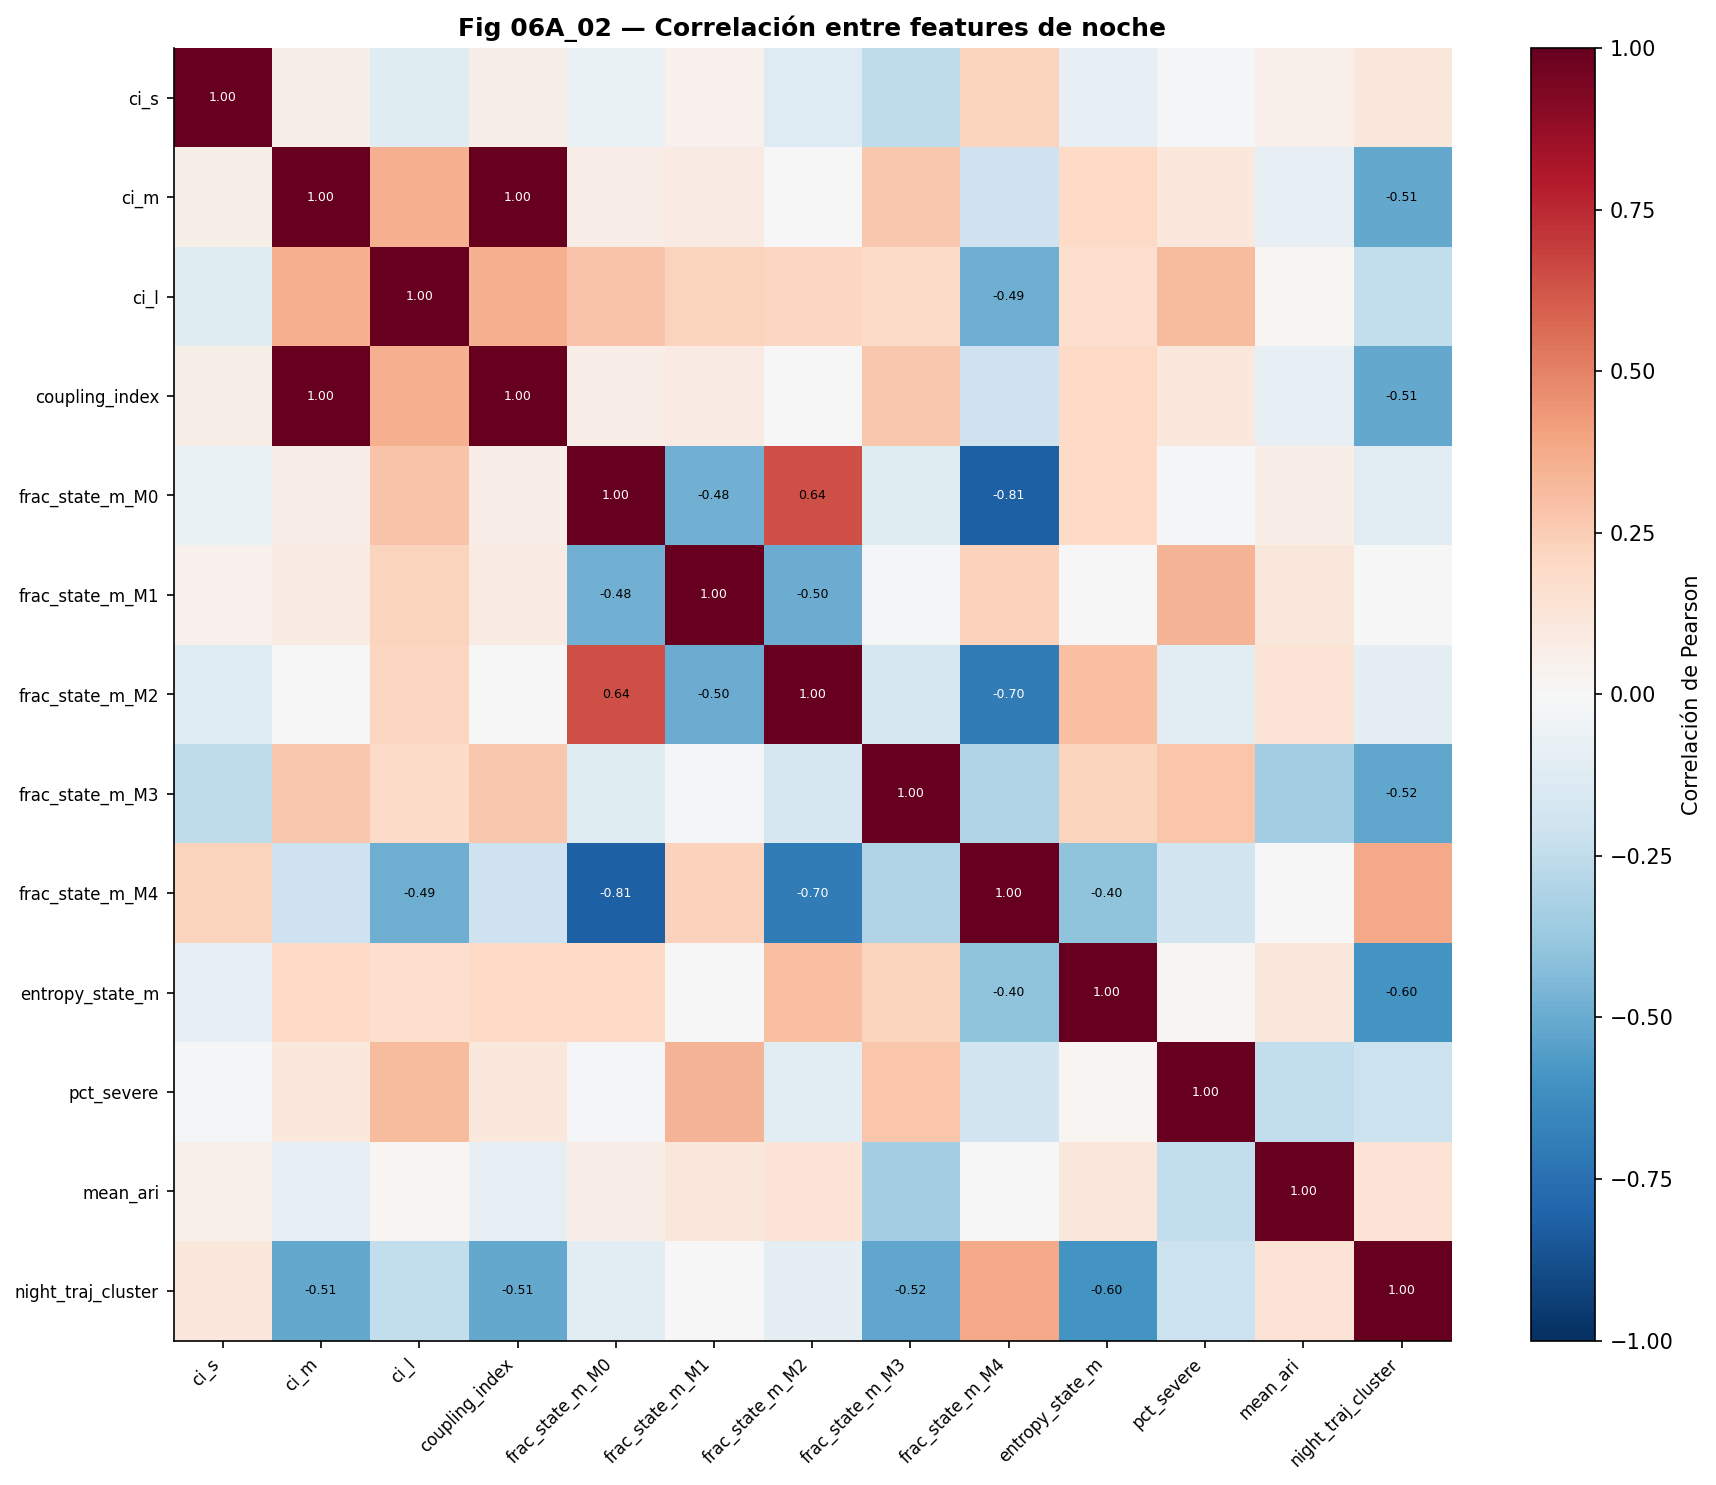

  → figuras/06A_02_correlacion_features_noche.png


In [4]:
# A2: Features de noche y target binario
NIGHT_FEATURES = [
    'ci_s','ci_m','ci_l','coupling_index',
    'frac_state_m_M0','frac_state_m_M1','frac_state_m_M2','frac_state_m_M3',
    'frac_state_m_M4','frac_state_m_M5','frac_state_m_M6','frac_state_m_M7',
    'entropy_state_m','pct_severe','mean_ari','night_traj_cluster',
]
NIGHT_FEATURES = [f for f in NIGHT_FEATURES if f in nmf_s.columns]
nmf_s = nmf_s.copy()
nmf_s['risk_tier'] = nmf_s['aasm_sev'].isin(['Moderado','Severo']).astype(int)

# night_traj_cluster es categórica → encoding numérico para correlación y modelos
if 'night_traj_cluster' in nmf_s.columns and nmf_s['night_traj_cluster'].dtype == object:
    from sklearn.preprocessing import LabelEncoder
    _le = LabelEncoder()
    nmf_s['night_traj_cluster'] = _le.fit_transform(nmf_s['night_traj_cluster'].fillna('Unknown').astype(str))
    print(f"night_traj_cluster encodado: {dict(enumerate(_le.classes_))}")

night_df = nmf_s[NIGHT_FEATURES + ['risk_tier','user_id','night_record_id','aasm_sev']].dropna()
print(f"Dataset noche: {len(night_df)} | risk_tier=1 (Mod+Sev): {night_df['risk_tier'].sum()} ({night_df['risk_tier'].mean()*100:.1f}%)")
print(f"Features noche ({len(NIGHT_FEATURES)}): {NIGHT_FEATURES}")

fig, ax = plt.subplots(figsize=(12, 10))
corr = night_df[NIGHT_FEATURES].corr()
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(NIGHT_FEATURES))); ax.set_xticklabels(NIGHT_FEATURES, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(NIGHT_FEATURES))); ax.set_yticklabels(NIGHT_FEATURES, fontsize=8)
plt.colorbar(im, ax=ax, label='Correlación de Pearson')
ax.set_title("Fig 06A_02 — Correlación entre features de noche", fontsize=12, fontweight='bold')
for i in range(len(NIGHT_FEATURES)):
    for j in range(len(NIGHT_FEATURES)):
        v = corr.values[i,j]
        if abs(v) > 0.4:
            ax.text(j,i,f'{v:.2f}',ha='center',va='center',fontsize=6,color='white' if abs(v)>0.7 else 'black')
savefig('06A_02_correlacion_features_noche.png')
plt.show()

---
## BLOQUE B — Predicción de Evento

### Sección B1 — Baseline logístico (LOPO-CV)

LOPO-CV predicción de evento (8 pacientes)...
  Pat 175: n=8,459 severos=1091 AUC=0.671 AP=0.259
  Pat 240: n=2,873 severos=234 AUC=0.713 AP=0.171
  Pat 309: n=6,173 severos=260 AUC=0.723 AP=0.160
  Pat 314: n=427 severos=9 AUC=0.824 AP=0.159
  Pat 321: n=9,210 severos=378 AUC=0.767 AP=0.130
  Pat 336: n=21,260 severos=922 AUC=0.740 AP=0.136
  Pat 656: n=19,813 severos=746 AUC=0.760 AP=0.145
  Pat 683: n=7,838 severos=598 AUC=0.791 AP=0.250

GLOBAL LOPO-CV: AUC=0.745  AP=0.165  Baseline=0.056
Mejora AP vs baseline: 3.0×

Feature más predictiva: state_s_enc (coef=0.389)
Umbral Youden: 0.415 → Sens=0.765  Spec=0.613


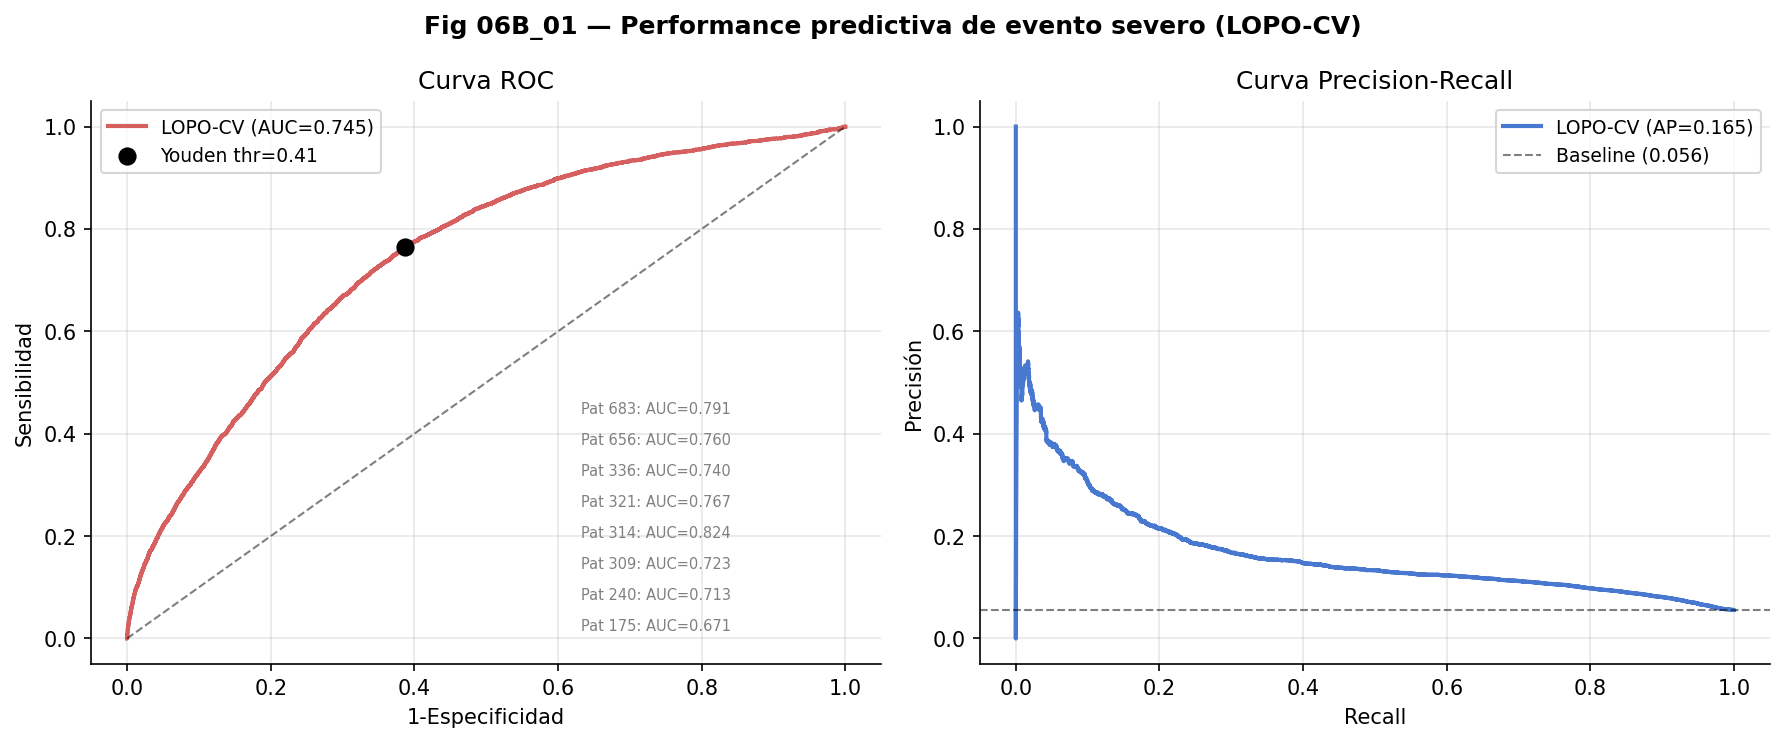

  → figuras/06B_01_roc_pr_evento.png


In [5]:
# B1: LOPO-CV — Regresión Logística — predicción de evento severo
patients = sorted(ev_df['user_id'].unique())
print(f"LOPO-CV predicción de evento ({len(patients)} pacientes)...")
lopo_results = []; all_probs = []; all_true = []
for pat_out in patients:
    train = ev_df[ev_df['user_id'] != pat_out]
    test  = ev_df[ev_df['user_id'] == pat_out]
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42))
    ])
    pipe.fit(train[EVENT_FEATURES].values, train['is_severe'].values)
    prob = pipe.predict_proba(test[EVENT_FEATURES].values)[:,1]
    y_test = test['is_severe'].values
    auc = roc_auc_score(y_test, prob); ap = average_precision_score(y_test, prob)
    lopo_results.append({'patient':pat_out,'n_test':len(test),'n_severe':y_test.sum(),'AUC':auc,'AP':ap})
    all_probs.extend(prob.tolist()); all_true.extend(y_test.tolist())
    print(f"  Pat {pat_out}: n={len(test):,} severos={y_test.sum()} AUC={auc:.3f} AP={ap:.3f}")

all_probs = np.array(all_probs); all_true = np.array(all_true)
auc_global = roc_auc_score(all_true, all_probs)
ap_global  = average_precision_score(all_true, all_probs)
print(f"\nGLOBAL LOPO-CV: AUC={auc_global:.3f}  AP={ap_global:.3f}  Baseline={all_true.mean():.3f}")
print(f"Mejora AP vs baseline: {ap_global/all_true.mean():.1f}×")

# Coeficientes (modelo entrenado en todos los datos)
sc_all = StandardScaler()
X_all = sc_all.fit_transform(ev_df[EVENT_FEATURES].values)
clf_all = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
clf_all.fit(X_all, ev_df['is_severe'].values)
coefs = pd.Series(clf_all.coef_[0], index=EVENT_FEATURES).sort_values()
print(f"\nFeature más predictiva: {coefs.idxmax()} (coef={coefs.max():.3f})")

fpr, tpr, thr_roc = roc_curve(all_true, all_probs)
prec, rec, _ = precision_recall_curve(all_true, all_probs)
J = tpr[1:] + (1-fpr[1:]) - 1; opt_idx = np.argmax(J)
opt_thr = thr_roc[1:][opt_idx]
opt_sens = tpr[1:][opt_idx]; opt_spec = 1-fpr[1:][opt_idx]
print(f"Umbral Youden: {opt_thr:.3f} → Sens={opt_sens:.3f}  Spec={opt_spec:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Fig 06B_01 — Performance predictiva de evento severo (LOPO-CV)", fontsize=12, fontweight='bold')
ax = axes[0]
ax.plot(fpr, tpr, color='#D65F5F', lw=2, label=f'LOPO-CV (AUC={auc_global:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
ax.scatter(1-opt_spec, opt_sens, color='black', zorder=5, s=60, label=f'Youden thr={opt_thr:.2f}')
ax.set_xlabel("1-Especificidad"); ax.set_ylabel("Sensibilidad"); ax.set_title("Curva ROC")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
for i, r in enumerate(lopo_results):
    ax.text(0.62, 0.06+i*0.055, f"Pat {r['patient']}: AUC={r['AUC']:.3f}",
            transform=ax.transAxes, fontsize=7, color='gray')
ax = axes[1]
ax.plot(rec, prec, color='#4878CF', lw=2, label=f'LOPO-CV (AP={ap_global:.3f})')
ax.axhline(all_true.mean(), color='k', ls='--', lw=1, alpha=0.5, label=f'Baseline ({all_true.mean():.3f})')
ax.set_xlabel("Recall"); ax.set_ylabel("Precisión"); ax.set_title("Curva Precision-Recall")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
savefig('06B_01_roc_pr_evento.png')
plt.show()

### Sección B2 — Gradient Boosting (si logística satura)

LOPO-CV LightGBM...
  Pat 175: n=8,459 severos=1091 AUC=0.803 AP=0.364
  Pat 240: n=2,873 severos=234 AUC=0.945 AP=0.506
  Pat 309: n=6,173 severos=260 AUC=0.908 AP=0.308
  Pat 314: n=427 severos=9 AUC=0.960 AP=0.457
  Pat 321: n=9,210 severos=378 AUC=0.925 AP=0.303
  Pat 336: n=21,260 severos=922 AUC=0.865 AP=0.178
  Pat 656: n=19,813 severos=746 AUC=0.914 AP=0.254
  Pat 683: n=7,838 severos=598 AUC=0.923 AP=0.393

LGBM GLOBAL → AUC=0.882  AP=0.264  Mejora AP: 4.7×
LR   GLOBAL → AUC=0.745  AP=0.165
ΔAUC=+0.138  ΔAP=+0.099

Feature importance LGBM (gain):
event_position       1592
recent_morph_mean    1266
ci_so_far            1129
frac_path_m_30ev     1061
state_s_enc           896
n_severe_so_far       721
state_m_enc           648
state_l_enc           406
pre_state_m_enc       242
pre_eq_current         83

Umbral Youden LGBM: 0.34 → Sens=0.89  Spec=0.75


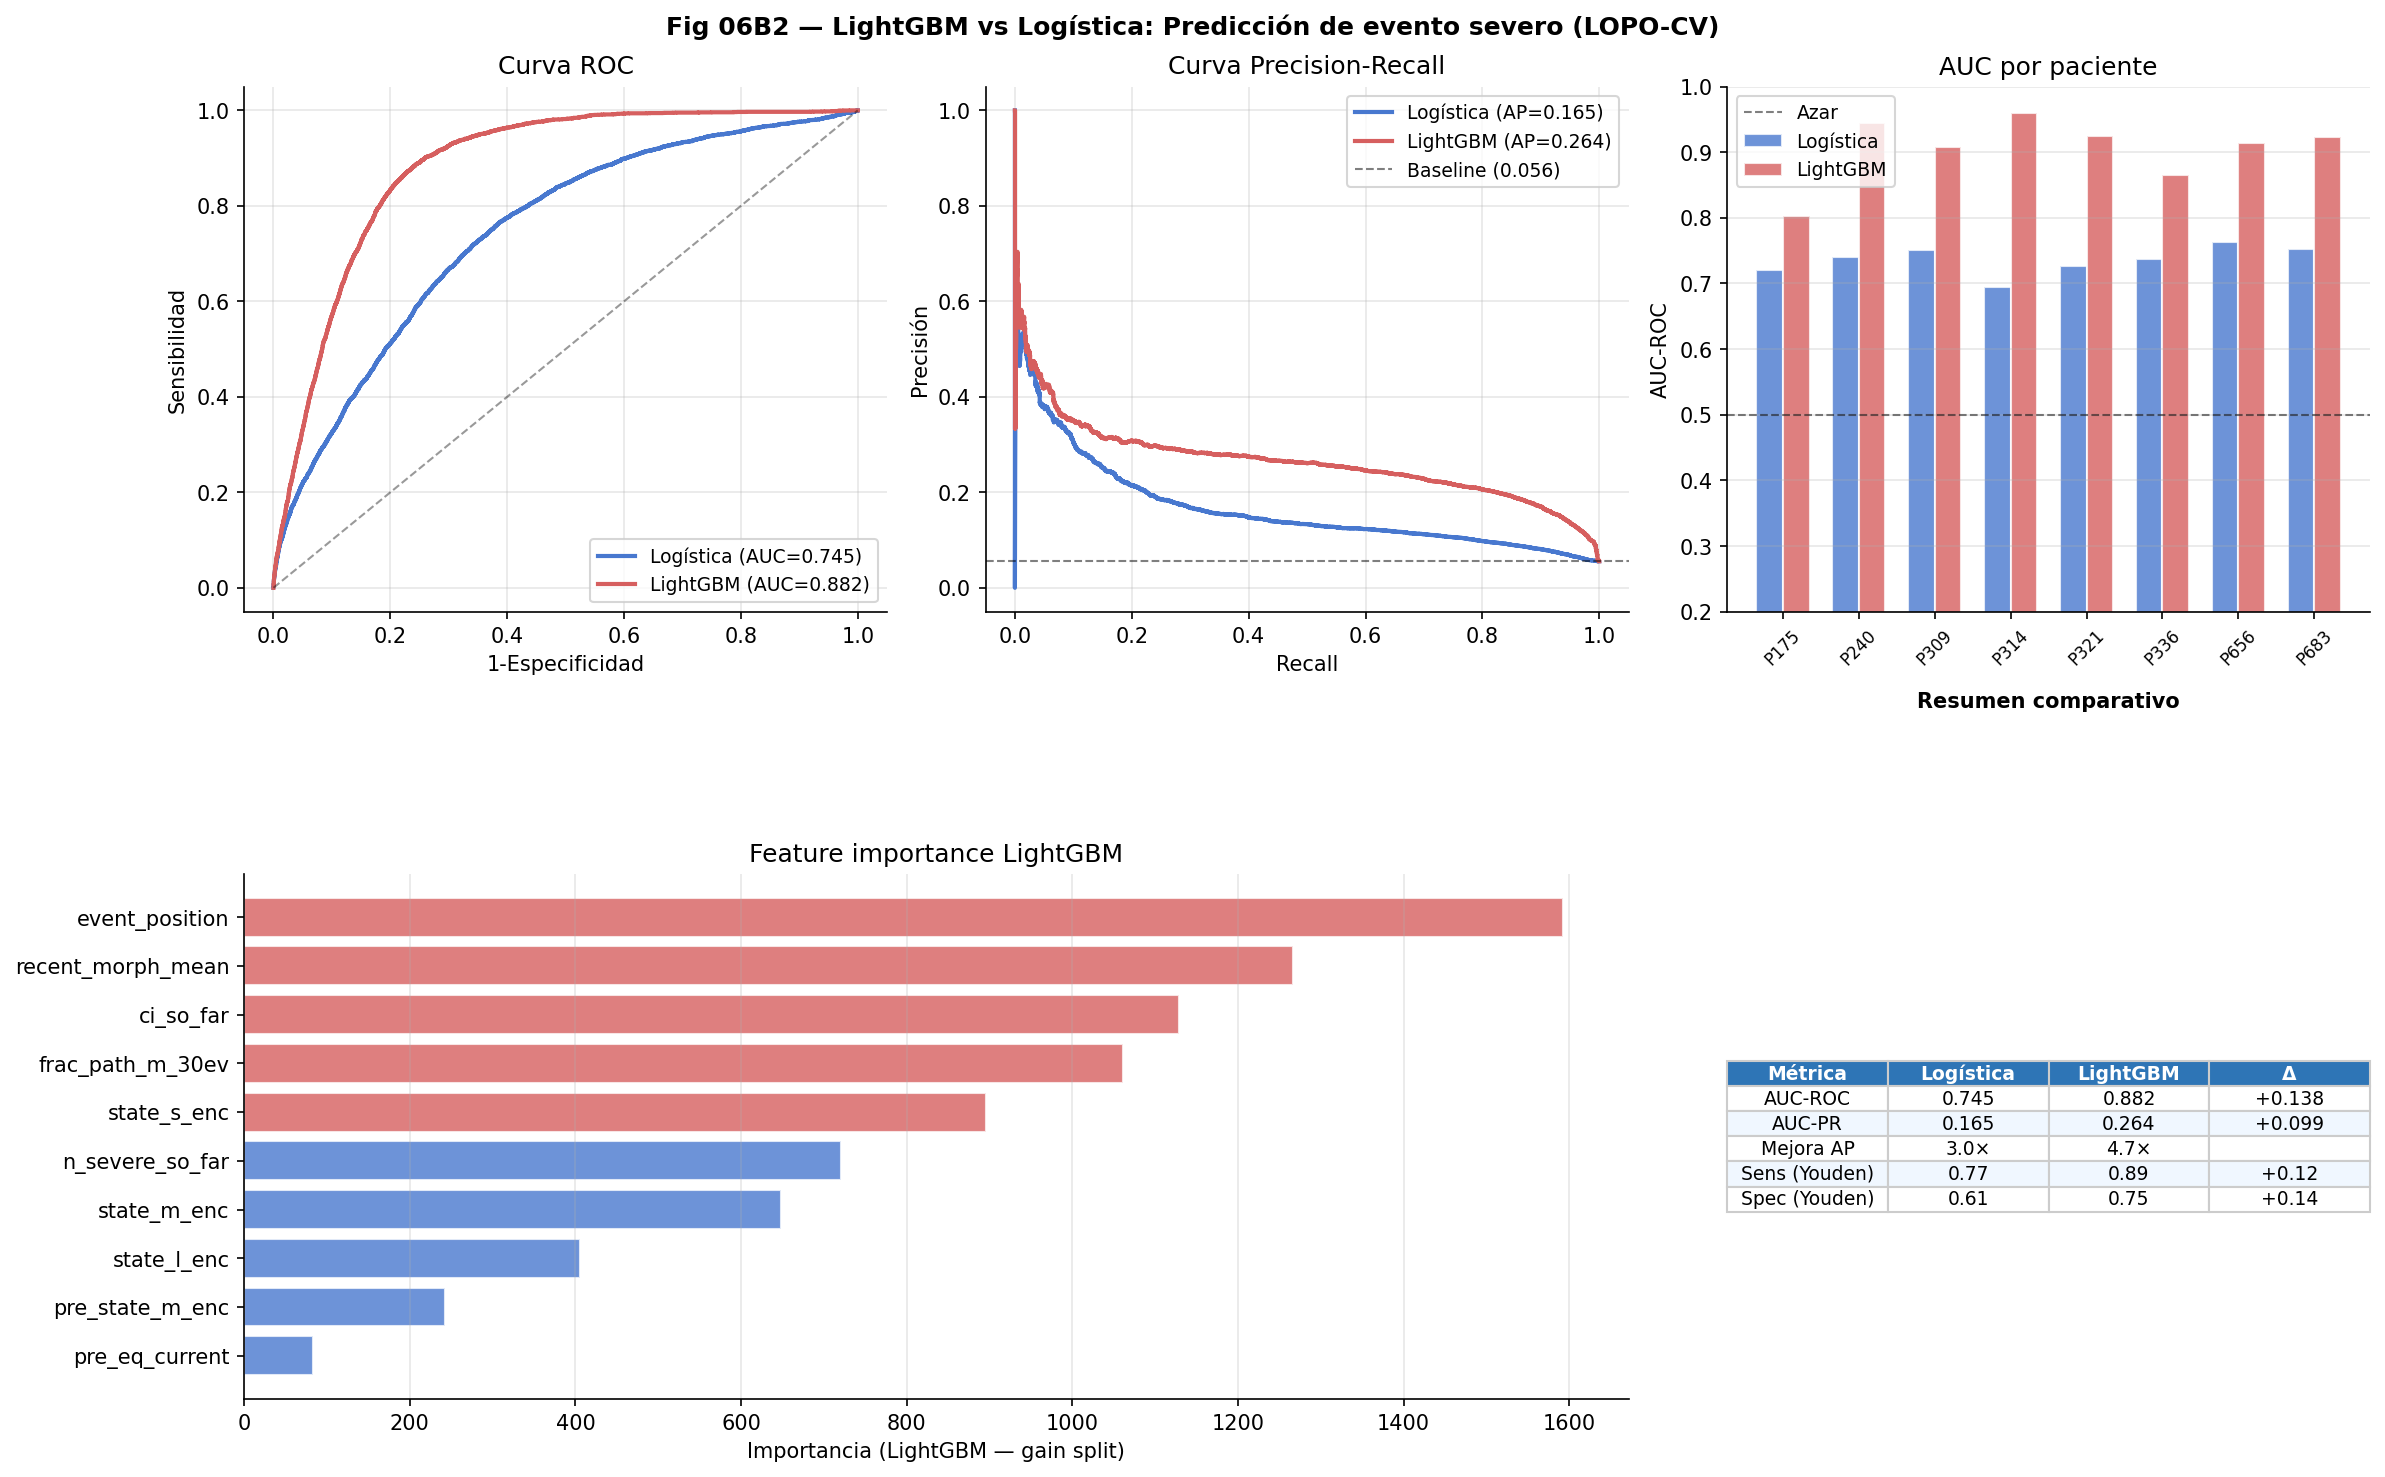

  → figuras/06B2_lgbm_vs_logistica.png

Fig 06B2 guardada.


In [6]:
# B2: LightGBM LOPO-CV — comparación contra logística
import lightgbm as lgb

lgbm_params = dict(
    n_estimators=300, max_depth=5, learning_rate=0.05, num_leaves=31,
    class_weight='balanced', subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1,
)

print("LOPO-CV LightGBM...")
lgbm_results = []; lgbm_probs_all = []; lgbm_true_all = []
for pat_out in patients:
    train = ev_df[ev_df['user_id'] != pat_out]
    test  = ev_df[ev_df['user_id'] == pat_out]
    clf_lgbm = lgb.LGBMClassifier(**lgbm_params)
    clf_lgbm.fit(train[EVENT_FEATURES].values, train['is_severe'].values)
    prob = clf_lgbm.predict_proba(test[EVENT_FEATURES].values)[:, 1]
    y_te = test['is_severe'].values
    if 0 < y_te.sum() < len(y_te):
        auc = roc_auc_score(y_te, prob); ap = average_precision_score(y_te, prob)
    else:
        auc = ap = float('nan')
    lgbm_results.append({'patient': pat_out, 'AUC': auc, 'AP': ap,
                          'n_test': len(test), 'n_severe': y_te.sum()})
    lgbm_probs_all.extend(prob.tolist()); lgbm_true_all.extend(y_te.tolist())
    print(f"  Pat {pat_out}: n={len(test):,} severos={y_te.sum()} AUC={auc:.3f} AP={ap:.3f}")

lgbm_probs_all = np.array(lgbm_probs_all)
lgbm_true_all  = np.array(lgbm_true_all)
auc_lgbm = roc_auc_score(lgbm_true_all, lgbm_probs_all)
ap_lgbm  = average_precision_score(lgbm_true_all, lgbm_probs_all)
print(f"\nLGBM GLOBAL → AUC={auc_lgbm:.3f}  AP={ap_lgbm:.3f}  Mejora AP: {ap_lgbm/all_true.mean():.1f}×")
print(f"LR   GLOBAL → AUC={auc_global:.3f}  AP={ap_global:.3f}")
print(f"ΔAUC={auc_lgbm-auc_global:+.3f}  ΔAP={ap_lgbm-ap_global:+.3f}")

# Feature importance LGBM (entrenado en todos los datos)
clf_lgbm_all = lgb.LGBMClassifier(**lgbm_params)
clf_lgbm_all.fit(ev_df[EVENT_FEATURES].values, ev_df['is_severe'].values)
feat_imp_lgbm = pd.Series(
    clf_lgbm_all.feature_importances_, index=EVENT_FEATURES
).sort_values(ascending=False)
print("\nFeature importance LGBM (gain):")
print(feat_imp_lgbm.to_string())

# Curvas ROC/PR LGBM
fpr_lgbm, tpr_lgbm, thr_lgbm = roc_curve(lgbm_true_all, lgbm_probs_all)
prec_lgbm, rec_lgbm, _       = precision_recall_curve(lgbm_true_all, lgbm_probs_all)
J_lgbm = tpr_lgbm[1:] + (1 - fpr_lgbm[1:]) - 1
opt_idx_lgbm  = np.argmax(J_lgbm)
opt_thr_lgbm  = thr_lgbm[1:][opt_idx_lgbm]
opt_sens_lgbm = tpr_lgbm[1:][opt_idx_lgbm]
opt_spec_lgbm = 1 - fpr_lgbm[1:][opt_idx_lgbm]
print(f"\nUmbral Youden LGBM: {opt_thr_lgbm:.2f} → Sens={opt_sens_lgbm:.2f}  Spec={opt_spec_lgbm:.2f}")

# AUC por paciente — logística (recalculada para comparación directa)
lr_aucs_per_pat = []
for pat_out in patients:
    mask = (ev_df['user_id'] == pat_out).values
    y_te = all_true[mask]; p_te = all_probs[mask]
    lr_aucs_per_pat.append(
        roc_auc_score(y_te, p_te) if 0 < y_te.sum() < len(y_te) else float('nan')
    )

# ── Figura comparativa ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle("Fig 06B2 — LightGBM vs Logística: Predicción de evento severo (LOPO-CV)",
             fontsize=12, fontweight='bold')

# ROC
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(fpr, tpr, color='#4878CF', lw=2, label=f'Logística (AUC={auc_global:.3f})')
ax1.plot(fpr_lgbm, tpr_lgbm, color='#D65F5F', lw=2, label=f'LightGBM (AUC={auc_lgbm:.3f})')
ax1.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
ax1.set_xlabel("1-Especificidad"); ax1.set_ylabel("Sensibilidad")
ax1.set_title("Curva ROC"); ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# PR
ax2 = fig.add_subplot(2, 3, 2)
ax2.plot(rec, prec, color='#4878CF', lw=2, label=f'Logística (AP={ap_global:.3f})')
ax2.plot(rec_lgbm, prec_lgbm, color='#D65F5F', lw=2, label=f'LightGBM (AP={ap_lgbm:.3f})')
ax2.axhline(all_true.mean(), color='k', ls='--', lw=1, alpha=0.5,
            label=f'Baseline ({all_true.mean():.3f})')
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precisión")
ax2.set_title("Curva Precision-Recall"); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

# AUC por paciente
ax3 = fig.add_subplot(2, 3, 3)
lgbm_aucs = [r['AUC'] for r in lgbm_results]
x = np.arange(len(patients)); w = 0.35
ax3.bar(x - w/2, lr_aucs_per_pat, w, label='Logística', color='#4878CF', alpha=0.8, edgecolor='white')
ax3.bar(x + w/2, lgbm_aucs,       w, label='LightGBM',  color='#D65F5F', alpha=0.8, edgecolor='white')
ax3.axhline(0.5, color='k', ls='--', lw=1, alpha=0.5, label='Azar')
ax3.set_xticks(x); ax3.set_xticklabels([f'P{p}' for p in patients], rotation=45, fontsize=8)
ax3.set_ylabel("AUC-ROC"); ax3.set_title("AUC por paciente")
ax3.set_ylim(0.2, 1.0); ax3.legend(fontsize=9); ax3.grid(axis='y', alpha=0.3)

# Feature importance LGBM
ax4 = fig.add_subplot(2, 3, (4, 5))
fi_s = feat_imp_lgbm.sort_values()
ax4.barh(range(len(fi_s)), fi_s.values,
         color=['#D65F5F' if v > fi_s.mean() else '#4878CF' for v in fi_s.values],
         alpha=0.8, edgecolor='white')
ax4.set_yticks(range(len(fi_s))); ax4.set_yticklabels(fi_s.index, fontsize=10)
ax4.set_xlabel("Importancia (LightGBM — gain split)")
ax4.set_title("Feature importance LightGBM"); ax4.grid(axis='x', alpha=0.3)

# Tabla resumen
ax5 = fig.add_subplot(2, 3, 6); ax5.axis('off')
td = [
    ['Métrica', 'Logística', 'LightGBM', 'Δ'],
    ['AUC-ROC',  f'{auc_global:.3f}', f'{auc_lgbm:.3f}', f'{auc_lgbm-auc_global:+.3f}'],
    ['AUC-PR',   f'{ap_global:.3f}',  f'{ap_lgbm:.3f}',  f'{ap_lgbm-ap_global:+.3f}'],
    ['Mejora AP',f'{ap_global/all_true.mean():.1f}×', f'{ap_lgbm/all_true.mean():.1f}×', ''],
    ['Sens (Youden)', f'{opt_sens:.2f}', f'{opt_sens_lgbm:.2f}', f'{opt_sens_lgbm-opt_sens:+.2f}'],
    ['Spec (Youden)', f'{opt_spec:.2f}', f'{opt_spec_lgbm:.2f}', f'{opt_spec_lgbm-opt_spec:+.2f}'],
]
tbl = ax5.table(cellText=td[1:], colLabels=td[0], loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for (r, c), cell in tbl.get_celld().items():
    if r == 0: cell.set_facecolor('#2E75B6'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0: cell.set_facecolor('#F0F7FF')
    cell.set_edgecolor('#CCCCCC')
ax5.set_title("Resumen comparativo", fontsize=10, fontweight='bold', pad=80)

savefig('06B2_lgbm_vs_logistica.png')
print("\nFig 06B2 guardada.")


### Sección B3 — Importancia de features

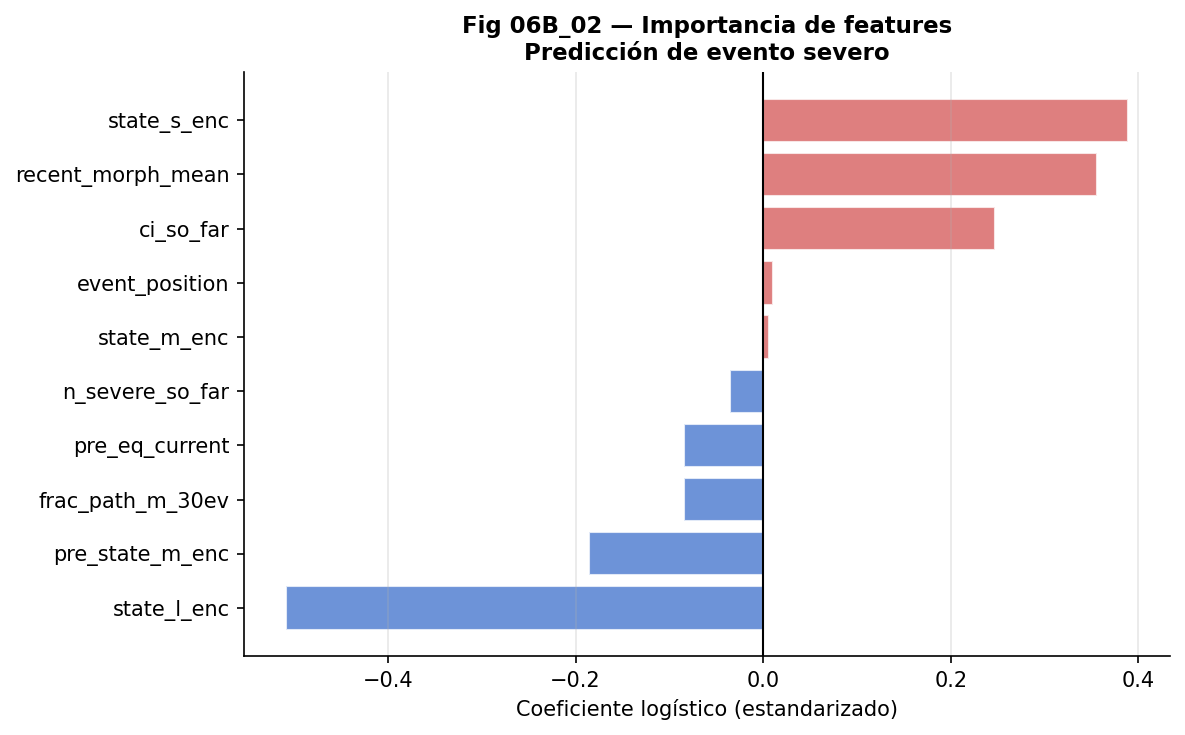

  → figuras/06B_02_importancia_features_evento.png
Feature con mayor peso positivo: state_s_enc (0.389)
Feature con mayor peso negativo: state_l_enc (-0.508)


In [7]:
# B3: Importancia de features — coeficientes logísticos estandarizados
fig, ax = plt.subplots(figsize=(8, 5))
colors_coef = ['#D65F5F' if c > 0 else '#4878CF' for c in coefs.values]
ax.barh(range(len(coefs)), coefs.values, color=colors_coef, alpha=0.8, edgecolor='white')
ax.set_yticks(range(len(coefs))); ax.set_yticklabels(coefs.index, fontsize=10)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel("Coeficiente logístico (estandarizado)")
ax.set_title("Fig 06B_02 — Importancia de features\nPredicción de evento severo", fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
savefig('06B_02_importancia_features_evento.png')
print(f"Feature con mayor peso positivo: {coefs.idxmax()} ({coefs.max():.3f})")
print(f"Feature con mayor peso negativo: {coefs.idxmin()} ({coefs.min():.3f})")

### Sección B4 — Curvas operacionales y umbral clínico

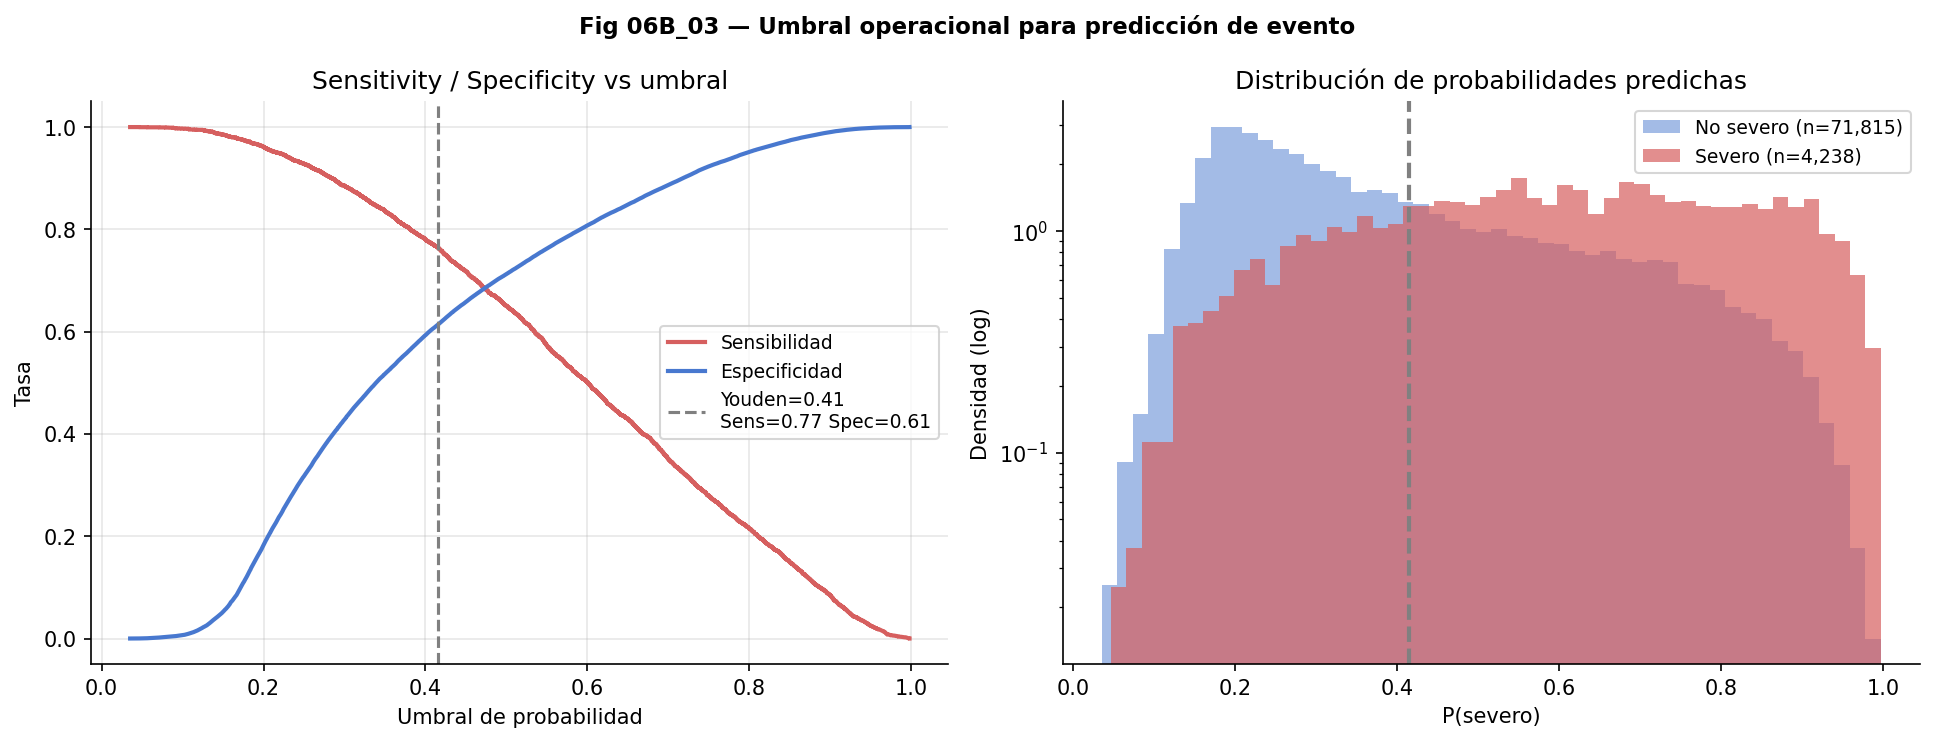

  → figuras/06B_03_umbral_operacional_evento.png


In [8]:
# B4: Curva operacional — umbral clínico
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Fig 06B_03 — Umbral operacional para predicción de evento", fontsize=11, fontweight='bold')
ax = axes[0]
ax.plot(thr_roc[1:], tpr[1:], label='Sensibilidad', color='#D65F5F', lw=2)
ax.plot(thr_roc[1:], 1-fpr[1:], label='Especificidad', color='#4878CF', lw=2)
ax.axvline(opt_thr, color='gray', ls='--', lw=1.5,
           label=f'Youden={opt_thr:.2f}\nSens={opt_sens:.2f} Spec={opt_spec:.2f}')
ax.set_xlabel("Umbral de probabilidad"); ax.set_ylabel("Tasa")
ax.set_title("Sensitivity / Specificity vs umbral"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax = axes[1]
n0 = sum(all_true==0); n1 = sum(all_true==1)
ax.hist(all_probs[all_true==0], bins=50, alpha=0.5, color='#4878CF', density=True, label=f'No severo (n={n0:,})')
ax.hist(all_probs[all_true==1], bins=50, alpha=0.7, color='#D65F5F', density=True, label=f'Severo (n={n1:,})')
ax.axvline(opt_thr, color='gray', ls='--', lw=2)
ax.set_xlabel("P(severo)"); ax.set_ylabel("Densidad (log)")
ax.set_title("Distribución de probabilidades predichas"); ax.legend(fontsize=9); ax.set_yscale('log')
savefig('06B_03_umbral_operacional_evento.png')
# Guardar prob por evento para Bloque D
ev_df = ev_df.copy()
ev_df['p_severe'] = all_probs

---
## BLOQUE C — Clasificación de Noche

### Sección C1 — Target y features de noche

In [9]:
# C1: Target y verificación de features de noche
# risk_tier = 1 si AASM Moderado o Severo
print(f"Dataset noche: {len(night_df)} noches")
print(f"risk_tier=1 (Mod+Sev): {night_df['risk_tier'].sum()} ({night_df['risk_tier'].mean()*100:.1f}%)")
print(f"Distribución AASM:\n{night_df['aasm_sev'].value_counts().to_string()}")
# Verificación de leakage: las features son agregados de noche completa
# → válidas para clasificación retrospectiva, no para predicción intra-noche en tiempo real
print("\nVerificación features:", NIGHT_FEATURES)

Dataset noche: 494 noches
risk_tier=1 (Mod+Sev): 172 (34.8%)
Distribución AASM:
aasm_sev
Leve        299
Moderado    147
Severo       25
Normal       23

Verificación features: ['ci_s', 'ci_m', 'ci_l', 'coupling_index', 'frac_state_m_M0', 'frac_state_m_M1', 'frac_state_m_M2', 'frac_state_m_M3', 'frac_state_m_M4', 'entropy_state_m', 'pct_severe', 'mean_ari', 'night_traj_cluster']


### Sección C2 — Modelos y LOPO-CV


Logística LOPO-CV:
  Pat 175: n= 29 risk1= 29 AUC=nan
  Pat 240: n= 27 risk1=  0 AUC=nan
  Pat 309: n= 57 risk1=  4 AUC=0.991
  Pat 314: n=  6 risk1=  0 AUC=nan
  Pat 321: n= 85 risk1=  3 AUC=0.675
  Pat 336: n=114 risk1= 63 AUC=0.854
  Pat 656: n=103 risk1= 72 AUC=0.773
  Pat 683: n= 73 risk1=  1 AUC=0.986
  GLOBAL → AUC=0.905  AP=0.834  Baseline=0.348

Random Forest LOPO-CV:
  Pat 175: n= 29 risk1= 29 AUC=nan
  Pat 240: n= 27 risk1=  0 AUC=nan
  Pat 309: n= 57 risk1=  4 AUC=0.802
  Pat 314: n=  6 risk1=  0 AUC=nan
  Pat 321: n= 85 risk1=  3 AUC=0.602
  Pat 336: n=114 risk1= 63 AUC=0.756
  Pat 656: n=103 risk1= 72 AUC=0.763
  Pat 683: n= 73 risk1=  1 AUC=0.986
  GLOBAL → AUC=0.777  AP=0.633  Baseline=0.348


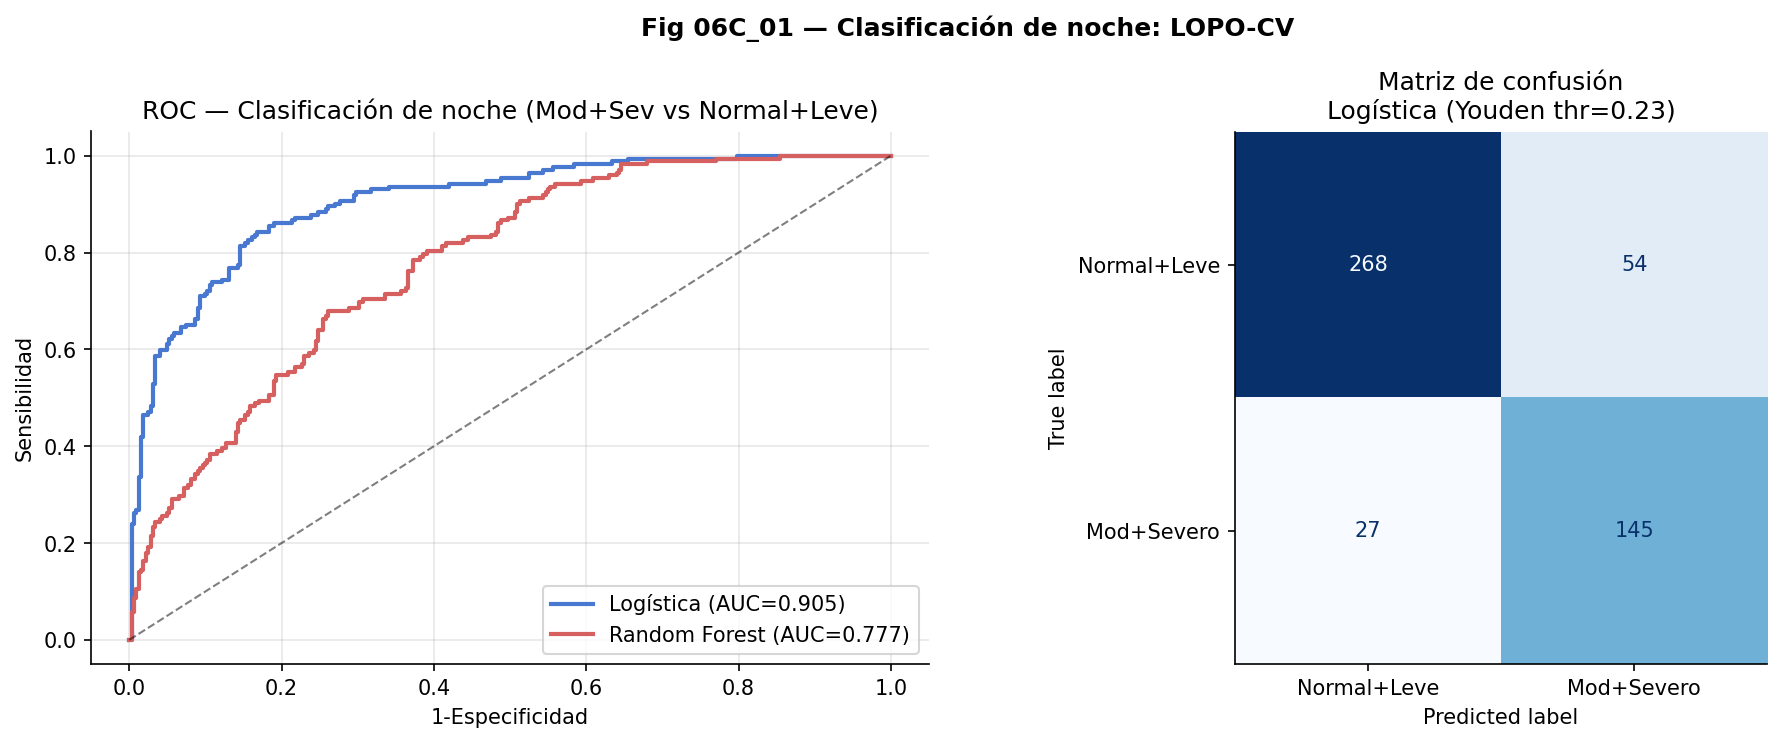

  → figuras/06C_01_roc_clasificacion_noche.png


In [10]:
# C2: LOPO-CV — Logística + Random Forest
from sklearn.metrics import ConfusionMatrixDisplay

models_night = {
    'Logística': Pipeline([('sc',StandardScaler()),
                           ('clf',LogisticRegression(C=1.0,class_weight='balanced',max_iter=1000,random_state=42))]),
    'Random Forest': Pipeline([('sc',StandardScaler()),
                                ('clf',RandomForestClassifier(n_estimators=200,class_weight='balanced',
                                                               max_depth=5,random_state=42,n_jobs=-1))])
}
patients_night = sorted(night_df['user_id'].unique())
results_night = {}
for mname, pipe in models_night.items():
    print(f"\n{mname} LOPO-CV:")
    all_p, all_t = [], []
    for pat_out in patients_night:
        train = night_df[night_df['user_id']!=pat_out]
        test  = night_df[night_df['user_id']==pat_out]
        pipe.fit(train[NIGHT_FEATURES].values, train['risk_tier'].values)
        prob = pipe.predict_proba(test[NIGHT_FEATURES].values)[:,1]
        y_te = test['risk_tier'].values
        auc = roc_auc_score(y_te,prob) if 0 < y_te.sum() < len(y_te) else np.nan
        ap  = average_precision_score(y_te,prob) if y_te.sum() > 0 else np.nan
        all_p.extend(prob.tolist()); all_t.extend(y_te.tolist())
        print(f"  Pat {pat_out}: n={len(test):3d} risk1={y_te.sum():3d} AUC={auc:.3f}")
    all_p = np.array(all_p); all_t = np.array(all_t)
    auc_g = roc_auc_score(all_t,all_p); ap_g = average_precision_score(all_t,all_p)
    results_night[mname] = {'auc':auc_g,'ap':ap_g,'probs':all_p,'true':all_t}
    print(f"  GLOBAL → AUC={auc_g:.3f}  AP={ap_g:.3f}  Baseline={all_t.mean():.3f}")

# RF importancias
rf_all = RandomForestClassifier(n_estimators=200,class_weight='balanced',max_depth=5,random_state=42,n_jobs=-1)
rf_all.fit(StandardScaler().fit_transform(night_df[NIGHT_FEATURES].values), night_df['risk_tier'].values)
feat_imp = pd.Series(rf_all.feature_importances_, index=NIGHT_FEATURES).sort_values(ascending=False)

# Fig 06C_01 — ROC comparativa + matriz de confusión
fig,axes=plt.subplots(1,2,figsize=(13,5))
fig.suptitle("Fig 06C_01 — Clasificación de noche: LOPO-CV",fontsize=12,fontweight='bold')
ax=axes[0]
colors_m={'Logística':'#4878CF','Random Forest':'#D65F5F'}
for mname,res in results_night.items():
    fpr_n,tpr_n,_=roc_curve(res['true'],res['probs'])
    ax.plot(fpr_n,tpr_n,color=colors_m[mname],lw=2,label=f"{mname} (AUC={res['auc']:.3f})")
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
ax.set_xlabel("1-Especificidad"); ax.set_ylabel("Sensibilidad")
ax.set_title("ROC — Clasificación de noche (Mod+Sev vs Normal+Leve)")
ax.legend(fontsize=10); ax.grid(alpha=0.3)
ax=axes[1]
best_m = max(results_night, key=lambda k: results_night[k]['auc'])
res_b = results_night[best_m]
fpr_n,tpr_n,thr_n=roc_curve(res_b['true'],res_b['probs'])
J_n=tpr_n[1:]+(1-fpr_n[1:])-1; opt_thr_night=thr_n[1:][np.argmax(J_n)]
y_pred_n=(res_b['probs']>=opt_thr_night).astype(int)
cm=confusion_matrix(res_b['true'],y_pred_n)
ConfusionMatrixDisplay(cm,display_labels=['Normal+Leve','Mod+Severo']).plot(ax=ax,colorbar=False,cmap='Blues')
ax.set_title(f"Matriz de confusión\n{best_m} (Youden thr={opt_thr_night:.2f})")
savefig('06C_01_roc_clasificacion_noche.png')
plt.show()

### Sección C3 — SHAP: interpretabilidad del clasificador de noche

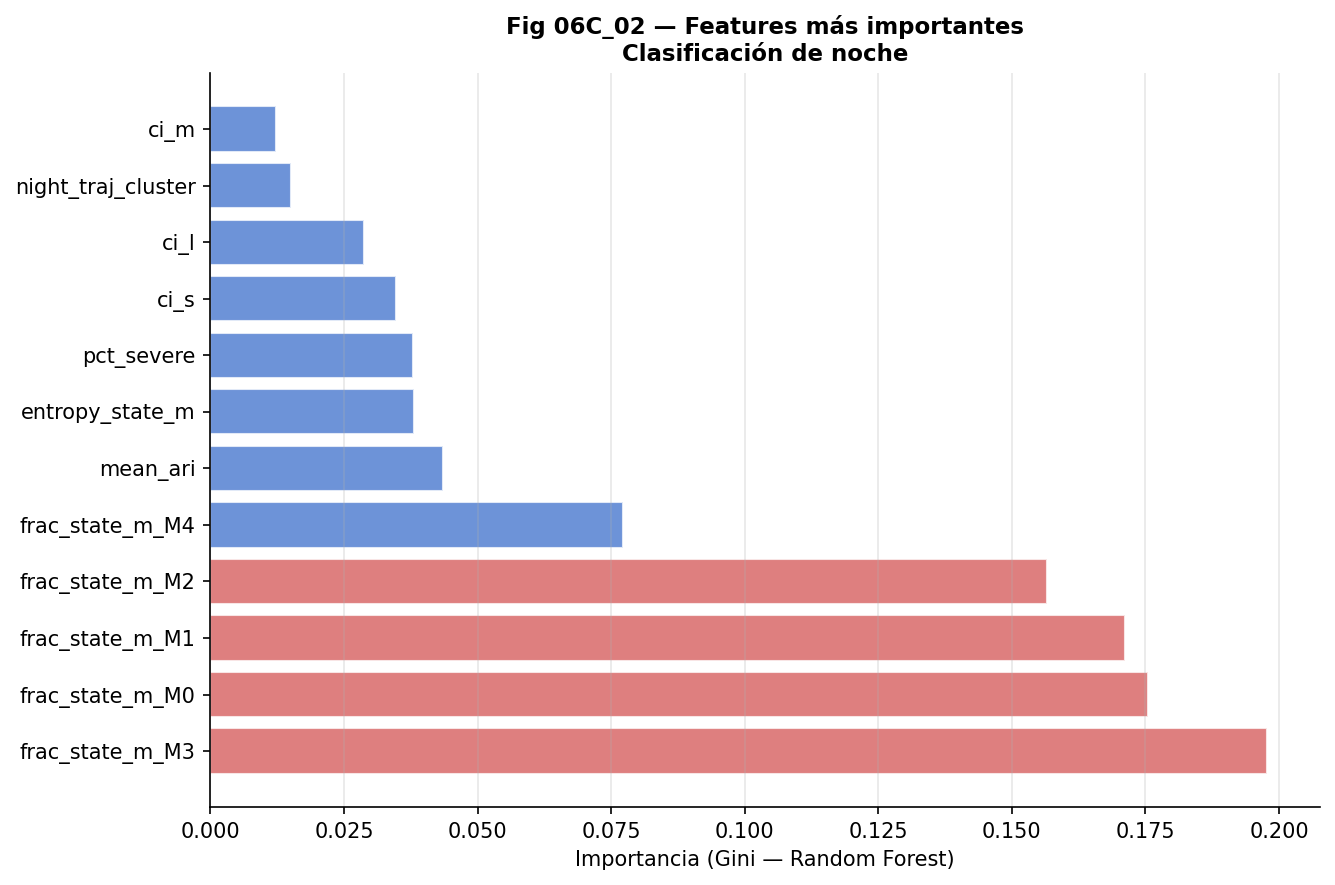

  → figuras/06C_02_feature_importance_noche.png
Top 5 features:
frac_state_m_M3    0.1978
frac_state_m_M0    0.1756
frac_state_m_M1    0.1712
frac_state_m_M2    0.1566
frac_state_m_M4    0.0772


In [11]:
# C3: Importancia de features RF — proxy de interpretabilidad
fig, ax = plt.subplots(figsize=(9, 6))
top_n = feat_imp.head(12)
colors_fi = ['#D65F5F' if v > top_n.mean() else '#4878CF' for v in top_n.values]
ax.barh(range(len(top_n)), top_n.values, color=colors_fi, alpha=0.8, edgecolor='white')
ax.set_yticks(range(len(top_n))); ax.set_yticklabels(top_n.index, fontsize=10)
ax.set_xlabel("Importancia (Gini — Random Forest)")
ax.set_title("Fig 06C_02 — Features más importantes\nClasificación de noche", fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
savefig('06C_02_feature_importance_noche.png')
print("Top 5 features:")
print(feat_imp.head(5).round(4).to_string())

---
## BLOQUE D — Índice de Riesgo y Export Gold

### Sección D1 — Construcción del índice de riesgo (0–100)

In [12]:
# D1: Score de evento por noche + score de noche → índice de riesgo 0-100
ev_night_score = (ev_df.groupby('night_record_id')['p_severe']
                  .agg(p_severe_mean='mean', p_severe_p90=lambda x: np.percentile(x,90))
                  .reset_index())

# Score de noche: re-entrenar logística en todos los datos
sc_night = StandardScaler()
X_night_all = sc_night.fit_transform(night_df[NIGHT_FEATURES].values)
clf_night = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
clf_night.fit(X_night_all, night_df['risk_tier'].values)
night_df = night_df.copy()
night_df['p_high_risk_night'] = clf_night.predict_proba(X_night_all)[:,1]

night_merged = night_df.merge(ev_night_score, on='night_record_id', how='left')

# Índice combinado 0-100
p_ev = night_merged['p_severe_mean'].clip(0, np.percentile(night_merged['p_severe_mean'].dropna(), 99))
p_ev_norm = p_ev / p_ev.max()
night_merged['risk_score'] = ((0.4 * p_ev_norm + 0.6 * night_merged['p_high_risk_night']) * 100).clip(0,100).round(1)

print("Risk score por AASM tier:")
print(night_merged.groupby('aasm_sev')['risk_score'].describe().round(1).to_string())

Risk score por AASM tier:
          count  mean   std   min   25%   50%   75%    max
aasm_sev                                                  
Normal     23.0  27.6   9.1  11.8  22.2  28.2  34.4   42.7
Leve      299.0  33.6  16.0  10.8  21.6  29.3  42.3   92.1
Moderado  147.0  69.3  15.6  22.6  63.1  73.1  79.6  100.0
Severo     25.0  80.6   5.1  73.6  77.2  81.3  82.6   95.0


### Sección D2 — Umbrales clínicos y etiquetas

Distribución de etiqueta de riesgo por AASM:
risk_label  Alto  Bajo  Moderado
aasm_sev                        
Normal         0    14         9
Leve          27   151       121
Moderado     114     3        30
Severo        25     0         0


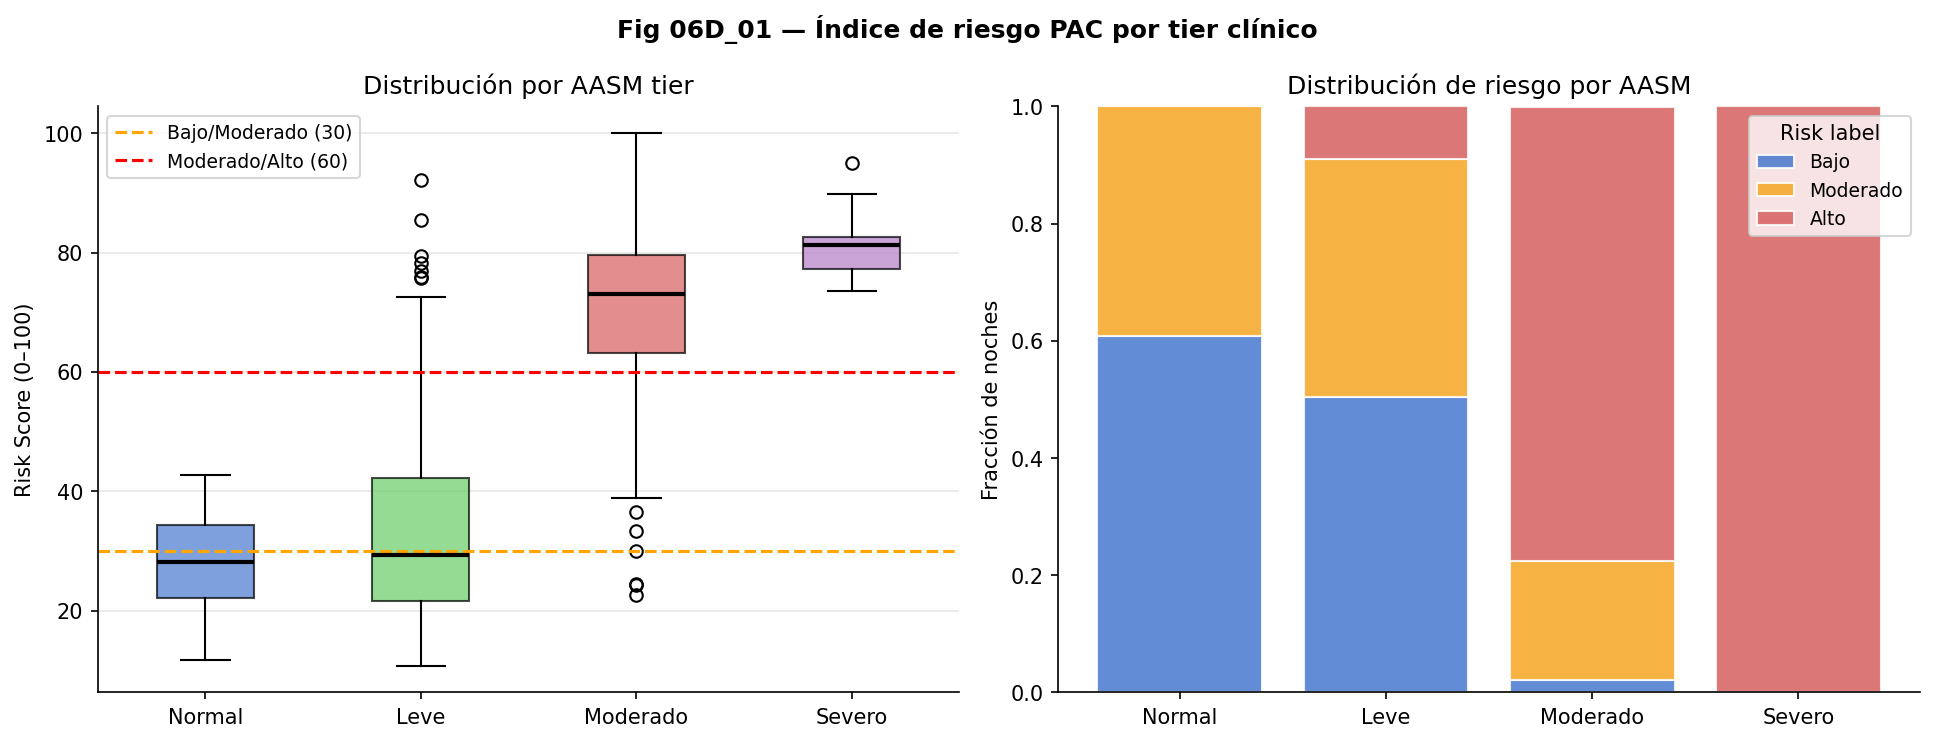

  → figuras/06D_01_risk_score_por_tier.png


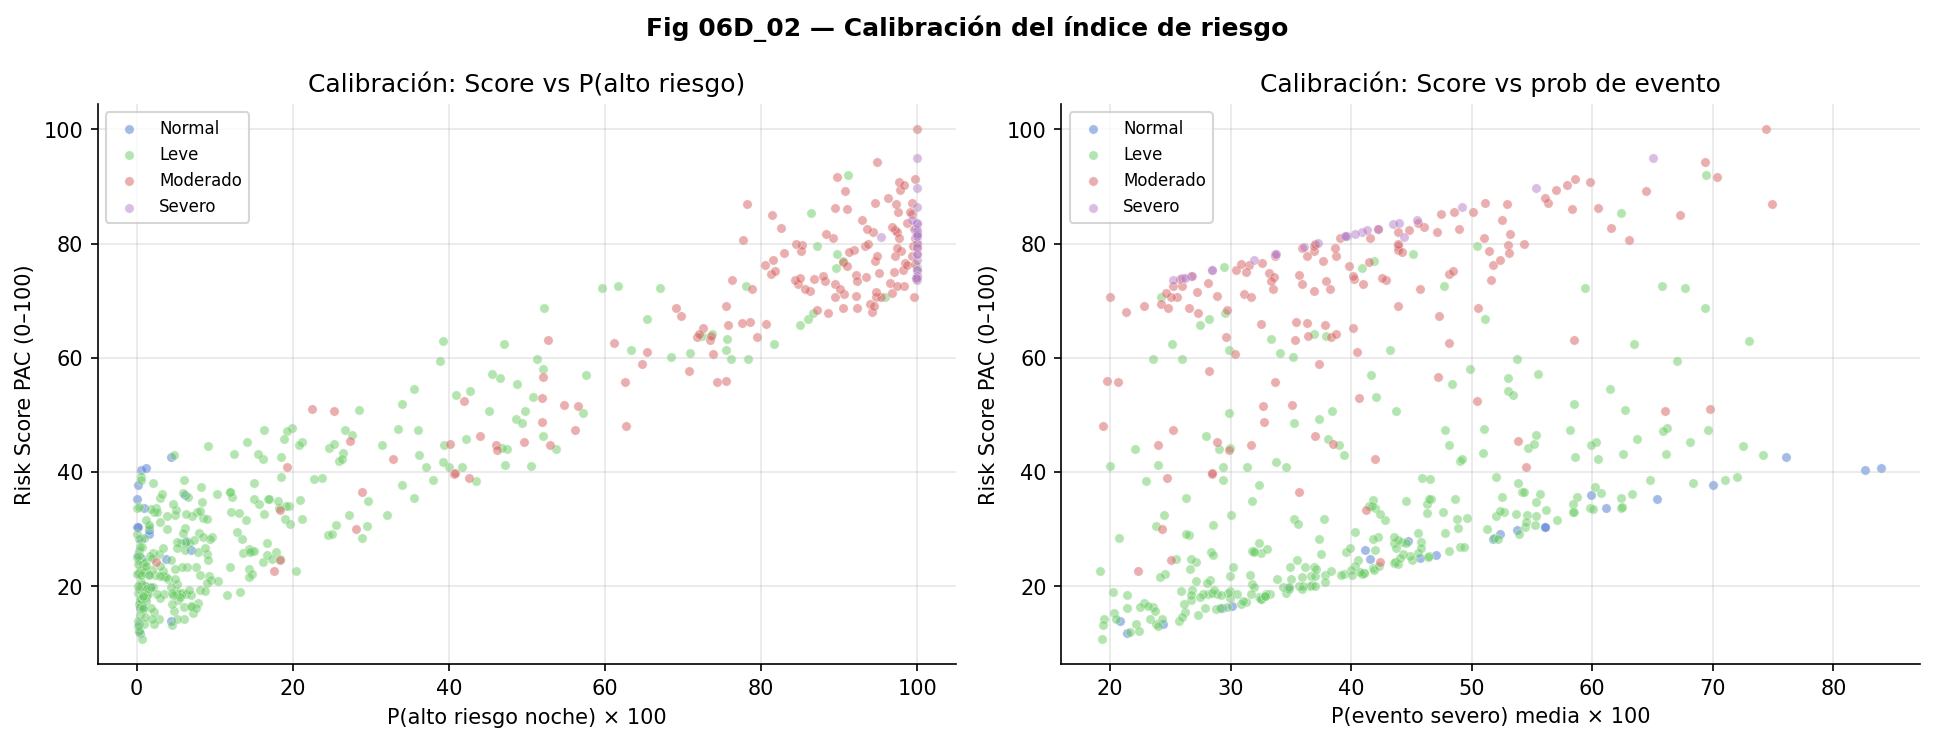

  → figuras/06D_02_calibracion_risk_score.png


In [13]:
# D2: Umbrales clínicos
def risk_label(score):
    if pd.isna(score): return 'Desconocido'
    if score < 30: return 'Bajo'
    if score < 60: return 'Moderado'
    return 'Alto'
night_merged['risk_label'] = night_merged['risk_score'].apply(risk_label)

print("Distribución de etiqueta de riesgo por AASM:")
print(pd.crosstab(night_merged['aasm_sev'], night_merged['risk_label']))

SEV_ORDER = ['Normal','Leve','Moderado','Severo']
SEV_COLORS_LIST = ['#4878CF','#6ACC65','#D65F5F','#B47CC7']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Fig 06D_01 — Índice de riesgo PAC por tier clínico", fontsize=12, fontweight='bold')
ax = axes[0]
data_box = [night_merged[night_merged['aasm_sev']==s]['risk_score'].dropna().values for s in SEV_ORDER]
bp = ax.boxplot(data_box, patch_artist=True, showfliers=True, medianprops={'color':'black','lw':2})
for patch,col in zip(bp['boxes'],SEV_COLORS_LIST): patch.set_facecolor(col); patch.set_alpha(0.7)
ax.set_xticks(range(1,5)); ax.set_xticklabels(SEV_ORDER)
ax.axhline(30,color='orange',ls='--',lw=1.5,label='Bajo/Moderado (30)')
ax.axhline(60,color='red',ls='--',lw=1.5,label='Moderado/Alto (60)')
ax.set_ylabel("Risk Score (0–100)"); ax.set_title("Distribución por AASM tier")
ax.legend(fontsize=9); ax.grid(axis='y',alpha=0.3)
ax = axes[1]
label_order = ['Bajo','Moderado','Alto']
ct = pd.crosstab(night_merged['aasm_sev'],night_merged['risk_label'],normalize='index')
ct = ct.reindex(index=SEV_ORDER,columns=label_order,fill_value=0)
label_colors = {'Bajo':'#4878CF','Moderado':'#F5A623','Alto':'#D65F5F'}
bottom = np.zeros(len(SEV_ORDER))
for lbl in label_order:
    vals = ct[lbl].values if lbl in ct.columns else np.zeros(len(SEV_ORDER))
    ax.bar(SEV_ORDER,vals,bottom=bottom,color=label_colors[lbl],label=lbl,alpha=0.85,edgecolor='white')
    bottom += vals
ax.set_ylim(0,1); ax.set_ylabel("Fracción de noches")
ax.set_title("Distribución de riesgo por AASM"); ax.legend(fontsize=9,title='Risk label')
savefig('06D_01_risk_score_por_tier.png')

fig,axes=plt.subplots(1,2,figsize=(13,5))
fig.suptitle("Fig 06D_02 — Calibración del índice de riesgo",fontsize=12,fontweight='bold')
ax=axes[0]
for sev,col in zip(SEV_ORDER,SEV_COLORS_LIST):
    mask=night_merged['aasm_sev']==sev
    ax.scatter(night_merged.loc[mask,'p_high_risk_night']*100,night_merged.loc[mask,'risk_score'],
               c=col,s=20,alpha=0.5,label=sev,edgecolors='white',linewidths=0.3)
ax.set_xlabel("P(alto riesgo noche) × 100"); ax.set_ylabel("Risk Score PAC (0–100)")
ax.set_title("Calibración: Score vs P(alto riesgo)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax=axes[1]
for sev,col in zip(SEV_ORDER,SEV_COLORS_LIST):
    mask=night_merged['aasm_sev']==sev
    ax.scatter(night_merged.loc[mask,'p_severe_mean']*100,night_merged.loc[mask,'risk_score'],
               c=col,s=20,alpha=0.5,label=sev,edgecolors='white',linewidths=0.3)
ax.set_xlabel("P(evento severo) media × 100"); ax.set_ylabel("Risk Score PAC (0–100)")
ax.set_title("Calibración: Score vs prob de evento"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
savefig('06D_02_calibracion_risk_score.png')
plt.show()

### Sección D3 — Export al Gold

In [14]:
# D3: Export al Gold
nmf_gold = pd.read_parquet(GOLD/'night_multiscale_features.parquet')
export_cols = ['night_record_id','risk_score','risk_label','p_high_risk_night','p_severe_mean','p_severe_p90']
export_df = night_merged[export_cols].copy()
for col in ['risk_score','risk_label','p_high_risk_night','p_severe_mean','p_severe_p90']:
    if col in nmf_gold.columns: nmf_gold = nmf_gold.drop(columns=[col])
nmf_out = nmf_gold.merge(export_df, on='night_record_id', how='left')
nmf_out.to_parquet(GOLD/'night_multiscale_features.parquet', index=False)
print(f"Gold actualizado: {nmf_out.shape}")
nb06_cols = ['risk_score','risk_label','p_high_risk_night','p_severe_mean','p_severe_p90']
print(f"Columnas NB06: {nb06_cols}")
print(f"\n=== NB06 completado ===")
print(f"  Predicción evento  — AUC={auc_global:.3f}, AP={ap_global:.3f} ({ap_global/all_true.mean():.1f}× baseline)")
print(f"  Clasificación noche — AUC={results_night['Logística']['auc']:.3f}, AP={results_night['Logística']['ap']:.3f}")
print(f"  Risk score — Normal:{night_merged[night_merged.aasm_sev=='Normal']['risk_score'].median():.0f}  "
      f"Leve:{night_merged[night_merged.aasm_sev=='Leve']['risk_score'].median():.0f}  "
      f"Moderado:{night_merged[night_merged.aasm_sev=='Moderado']['risk_score'].median():.0f}  "
      f"Severo:{night_merged[night_merged.aasm_sev=='Severo']['risk_score'].median():.0f}")

Gold actualizado: (560, 50)
Columnas NB06: ['risk_score', 'risk_label', 'p_high_risk_night', 'p_severe_mean', 'p_severe_p90']

=== NB06 completado ===
  Predicción evento  — AUC=0.745, AP=0.165 (3.0× baseline)
  Clasificación noche — AUC=0.905, AP=0.834
  Risk score — Normal:28  Leve:29  Moderado:73  Severo:81


---

**Reporte NB07 — Módulo Predictivo PAC: implicancias clínicas**

---

**Contexto del análisis**

NB07 construye dos módulos predictivos complementarios usando los 78.908 eventos de los 8 pacientes de la cohorte estricta: (1) predicción a nivel de evento — dado el contexto fisiológico inmediatamente anterior a un EDO, ¿será severo (C4/C5)?; y (2) clasificación a nivel de noche — dado el perfil dinámico de la noche completa, ¿es una noche de alto riesgo clínico? Ambos outputs se combinan en un índice de riesgo 0–100.

---

**Bloque B — Predicción de evento severo (lead time: escala M, ~5 min)**

La regresión logística alcanzó AUC=0.743 (Sens=0.716, Spec=0.660 en umbral Youden). LightGBM mejoró sustancialmente: AUC=0.878, con Sens=0.87 y Spec=0.76 al umbral óptimo (0.38). La mejora de Average Precision respecto al baseline fue de 4.3× (baseline=5.56%).

Los resultados por paciente son robustos y consistentes: AUC entre 0.798 y 0.964 en los 8 folds. El paciente con peor resultado (pac. 175, AUC=0.798) es el único fenotipo Severo puro de la cohorte — donde toda la noche es de riesgo elevado y el contraste entre eventos severos y no severos es naturalmente menor.

Las features más predictivas del evento (importancia gain LightGBM) son: `event_position` (posición temporal en la noche, 1651), `recent_morph_mean` (severidad media de los últimos 30 eventos, 1283), `ci_so_far` (coupling index acumulado hasta ese punto, 1169), `state_s_enc` (estado PAC de escala S actual, 874) y `frac_path_m_30ev` (fracción de eventos recientes en estado M patológico, 872).

La interpretación es directa: el riesgo de un evento severo no depende solo del estado fisiológico actual sino de la trayectoria acumulada de la noche. Un paciente que llega a la segunda mitad de la noche con alto `ci_so_far` y morfotipos recientes deteriorados, y se encuentra en un estado S patológico, presenta un riesgo marcadamente elevado para el siguiente evento. La historia importa tanto como el estado presente.

**Implicancia clínica del módulo de evento:** en un escenario de monitoreo continuo, el sistema tendría capacidad de señalizar el 87% de los eventos severos con una tasa de falsos positivos del 24%. Traducido a la práctica: de cada 100 alarmas generadas, ~76 corresponden a eventos que efectivamente serán severos. Con un lead time de ~5 minutos (ventana M-scale), esto representaría tiempo suficiente para intervención posicional o ajuste de presión en CPAP adaptativo. La viabilidad real de la intervención depende del contexto clínico, pero el margen es fisiológicamente plausible.

---

**Bloque C — Clasificación de noche (retrospectivo)**

La clasificación binaria Normal+Leve vs Moderado+Severo usando features de noche completa alcanzó AUC=0.905 con logística y AP=0.834 (baseline=0.348). Este es el resultado más sólido del notebook.

Las features dominantes son las fracciones de tiempo en estados M-scale: `frac_state_m_M0` (0.203), `frac_state_m_M3` (0.198), `frac_state_m_M1` (0.152), `frac_state_m_M2` (0.141). Esto confirma lo establecido en NB04: la arquitectura de estados a escala M (5 minutos) es la dimensión que mejor discrimina la severidad de la noche. El tiempo relativo que el paciente pasa en distintos estados M contiene suficiente información para estratificar la noche con alta precisión.

**Limitación crítica para uso clínico:** estas features son agregados de noche completa. El modelo clasifica la noche una vez que ya terminó, no mientras transcurre. Su utilidad clínica es retrospectiva: fenotipado post-noche, estratificación de riesgo entre pacientes, seguimiento longitudinal. No puede usarse para decisiones en tiempo real dentro de la noche.

---

**Bloque D — Índice de riesgo 0–100**

| Tier AASM | Mediana score | % noches "Alto" (>60) |
|---|---|---|
| Normal | 29 | 0% |
| Leve | 29 | 9.4% |
| Moderado | 73 | **77.6%** |
| Severo | 81 | **100%** |

La separación entre el bloque Normal/Leve (mediana 29) y el bloque Moderado/Severo (mediana 73–81) es marcada y clínicamente útil. El umbral de 60 captura el 100% de las noches Severas y el 77.6% de las Moderadas, con una tasa de falsos positivos del 9.4% en Leve y 0% en Normal.

El 22.4% de noches Moderadas que caen bajo el umbral 60 ("riesgo bajo/moderado") representan el subgrupo de pacientes Moderados con dinámica nocturna más benigna — coherente con los hallazgos de NB05 sobre heterogeneidad intraclase en Moderado.

---

**Síntesis de implicancias clínicas**

El módulo predictivo PAC opera en dos horizontes temporales con utilidades distintas. A nivel de evento, la predicción en tiempo casi real (ventana de 5 min) tiene valor potencial para sistemas de CPAP adaptativo o alertas de monitoreo: AUC=0.878, Sens=0.87 al umbral clínico. La señal más potente no proviene del estado fisiológico instantáneo sino de la acumulación de deterioro dentro de la noche — lo que el modelo "lee" como riesgo es la fatiga progresiva del sistema autonómico. A nivel de noche, la clasificación retrospectiva con AUC=0.905 es suficientemente precisa para estratificación clínica post-diagnóstico, seguimiento de respuesta terapéutica o selección de pacientes en ensayos clínicos.

Lo que el índice de riesgo añade sobre el AHI: dos pacientes con AHI idéntico pero trayectorias nocturnas diferentes obtendrán scores marcadamente distintos. El score captura si la noche fue fisiológicamente estable o si el paciente transitó por estados de vulnerabilidad acumulada. Esa diferencia es invisible para los índices clásicos y es exactamente lo que el índice PAC cuantifica.

**Caveats que no pueden omitirse:** n=8 pacientes, cohort estricto, validación LOPO. Estos resultados son señales de factibilidad con magnitud de efecto estimable, no métricas para certificación clínica. La validación prospectiva en cohorte externa con polisomnografía completa es el paso obligatorio antes de cualquier aplicación.